# Taller 4 — Mini-proyecto de generación de texto con GPT
## Caso propio: satisfacción de clientes de e-commerce en español a partir de sus reseñas (1–5 estrellas)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yeavil-neny/NLP-ProcesamientoLeguajeNatural/blob/main/Taller_4/proyecto_gpt_resenas_ecommerce.ipynb)

**Equipo:** Fredy Alvarez · Anderson Pipicano · Cristian Yepes · Yenny Villarreal

---

### El problema (el mismo hilo conductor de los talleres anteriores)

A lo largo del curso hemos trabajado un único problema real: **predecir la satisfacción de un cliente
de e-commerce en español leyendo su reseña de producto**, en una escala de 1 a 5 estrellas.

- **Taller 1 (LSTM):** red recurrente entrenada desde cero → acc 0.5168
- **Taller 2 (Transformer desde cero):** clasificador con embeddings estáticos → acc 0.4896
- **Taller 3 (BERT, encoder):** featurizer congelado y fine tuning completo → acc 0.5734 (mejor hasta ahora)

En este taller la pregunta cambia de ángulo. La clase trató los modelos **GPT (decoder,
autoregresivos, orientados a *generar* texto)**. Entonces: **¿puede un modelo nacido para
escribir también servir para *clasificar* la satisfacción?** La hipótesis es doble:

1. **H1:** la representación interna de un GPT-2 pre-entrenado en español ya codifica señal
   de sentimiento (aunque no se haya entrenado para eso) → sirviendo como *featurizer* congelado
   debería superar a un featurizer de embeddings estáticos y acercarse al BERT del Taller 3.
2. **H2:** con fine tuning (una capa de clasificación sobre el decoder completa), GPT-2
   debería ser competitivo con BERT: ambos son transformers pre-entrenados; lo que cambia es
   *encoder bidireccional* (ve el contexto a ambos lados) vs. *decoder unidireccional*
   (solo ve hacia atrás, el mismo mecanismo que usa cuando predice la siguiente palabra).

### Por qué nuestra propuesta es buena para abordar el problema

- **Mismo corpus, mismos submuestreos de los talleres anteriores** (`SetFit/amazon_reviews_multi_es`,
  50k train / 5k val / 5k test, seed 42): la comparación con el historial del curso es directa y justa.
- **Progresión de dificultad en gradiente** (zero-shot → featurizer → fine tuning → generativo):
  cada experimento aísla una idea distinta y nos permite *entender* de dónde viene cada mejora.
- **Vale la pena**: la clasificación de satisfacción es la tarea de negocio que venimos estudiando,
  pero con un modelo generativo podemos además **demostrar generación condicionada**: entrenamos
  a GPT para escribir reseñas sintéticas de la calidad que le pidamos — un puente natural
  entre "clasificar" y "generar", y la demo más memorable de la clase llevada a nuestro caso.

### Matriz de experimentos

| Exp | Técnica | Origen respecto a la clase |
|---|---|---|
| **E0** | Clasificación *zero-shot* por log-verosimilitud (GPT-2 sin entrenar) | Más allá de la clase (prompting con likelihood) |
| **E1a** | GPT-2 congelado como featurizer + regresión logística | Análogo al Taller 3 (encoder→decoder) |
| **E1b** | GPT-2 congelado como featurizer + MLP | Análogo al Taller 3 |
| **E2** | Fine tuning para clasificación (`GPT2ForSequenceClassification`) | Núcleo del taller (adaptado de generación→clasificación) |
| **E3a** | Fine tuning generativo (LM puro) **condicionado por la etiqueta de estrellas** | La guía de clase, con nuestra modificación: prefijo 'Estrellas: n.' |
| **E3b** | Demo: generar reseñas sintéticas de N estrellas (antes vs. después del fine tuning) | Demo propia |
| — | Curvas de entrenamiento, matriz de confusión, severidad ±1★, tabla comparativa global T1–T4 | Análisis agregado |

> ⚙️ **Reproducibilidad:** semilla fija en todo el notebook. La variable `SMOKE_TEST` (celda de
> configuración) permite correr una versión reducida en minutos para verificar que todo funciona;
> la versión de entrega corresponde a `SMOKE_TEST = False` con la corrida completa en Colab (GPU).


In [67]:
# ─────────────────────────────────────────────────────────────────────
# 0. PREPARACIÓN DEL ENTORNO
# ─────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# Dependencias que pueden no venir preinstaladas (en Colab casi todas están);
# si falta alguna, la instalamos silenciosamente.
import importlib.util, subprocess, sys
for pkg in ['datasets', 'wordcloud', 'nltk']:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import transformers
from datasets import load_dataset, DatasetDict
from transformers import (AutoTokenizer, AutoModel, AutoModelForCausalLM,
                          AutoModelForSequenceClassification,
                          DataCollatorForLanguageModeling,
                          Trainer, TrainingArguments, set_seed)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

torch.manual_seed(42)
set_seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ─── CONFIGURACIÓN GLOBAL ────────────────────────────────────────────
# SMOKE_TEST=True  -> corre rápido con muestras pequeñas (prueba estructural)
# SMOKE_TEST=False -> corrida COMPLETA de entrega (en Colab, con GPU)
SMOKE_TEST = False

MODEL_NAME = 'mrm8488/spanish-gpt2'   # el GPT-2 en español de la clase
SEED = 42

print(f'PyTorch: {torch.__version__} | Transformers: {transformers.__version__} | Device: {device}')
print(f'SMOKE_TEST: {SMOKE_TEST}')

PyTorch: 2.11.0+cu128 | Transformers: 5.16.1 | Device: cuda
SMOKE_TEST: False


## 1. El dataset: reseñas de Amazon en español

Usamos **exactamente el mismo dataset y submuestreos de los Talleres 1, 2 y 3**
(`SetFit/amazon_reviews_multi_es`, submuestreos de 50 000 reseñas para entrenamiento y 5 000
para validación y prueba, semilla 42). El dataset original tiene 200 000 reseñas de Amazon
en español etiquetadas de 1 a 5 estrellas, balanceado por clase.

> 🔁 Decisión de diseño: NO cambiar el dataset. Un caso "propio" bien construido no
> necesariamente estrena corpus: nuestro caso es propio porque **cambia el paradigma del
> modelo** (encoder→decoder, generación→clasificación), y al conservar el muestreo, la tabla
> comparativa final mide el efecto del modelo y no el efecto del dataset.

In [68]:
# Cargamos el dataset de reseñas de Amazon en español (mismo del Taller 1, 2 y 3)
print("Descargando el dataset 'SetFit/amazon_reviews_multi_es'...")
dataset = load_dataset("SetFit/amazon_reviews_multi_es")

# Mismo submuestreo de los talleres anteriores (semilla fija -> reproducible).
# Si SMOKE_TEST, tomamos muestras pequeñas solo para validar que todo corre.
if SMOKE_TEST:
    n_train, n_eval = 1000, 500
else:
    n_train, n_eval = 50000, 5000

train_data = dataset['train'].shuffle(seed=SEED).select(range(n_train))
val_data   = dataset['validation'].shuffle(seed=SEED).select(range(n_eval))
test_data  = dataset['test'].shuffle(seed=SEED).select(range(n_eval))

# Nombres bonitos para las clases (el dataset trae 0..4; pasamos a 1..5 estrellas)
id2label = {0: '1★', 1: '2★', 2: '3★', 3: '4★', 4: '5★'}
label2id = {v: k for k, v in id2label.items()}
NUM_CLASSES = 5

splits = DatasetDict({'train': train_data, 'val': val_data, 'test': test_data})

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")
print(f"Columnas: {train_data.column_names}")
print(f"\n--- Ejemplo (train[0]) ---")
print(f"Texto  : {train_data[0]['text'][:300]}")
print(f"Estrellas: {train_data[0]['label'] + 1}")

Descargando el dataset 'SetFit/amazon_reviews_multi_es'...


Repo card metadata block was not found. Setting CardData to empty.


Train: 50000 | Val: 5000 | Test: 5000
Columnas: ['id', 'text', 'label', 'label_text']

--- Ejemplo (train[0]) ---
Texto  : La montarlo se rompió una rueda debido a materiales débiles, pero al arreglarla funciona correctamente.
Estrellas: 3


In [69]:
# Un vistazo a una reseña de cada clase para 'enchularnos' del dominio
df_peek = train_data.to_pandas()
df_peek['estrellas'] = df_peek['label'] + 1
for n in range(1, 6):
    row = df_peek[df_peek['estrellas'] == n].iloc[0]
    print(f"── {n}★ ── {row['text'][:220]}")
    print()

── 1★ ── Tiene 6 meses y ya se ha roto una goma

── 2★ ── El servicio ha sido muy bueno, me ha llegado 2 días antes de lo previsto. En cuanto al producto no es que me haya dado muy buenas primeras impresiones. El borde del protector es de plástico y lo único que hay de cristal 

── 3★ ── La montarlo se rompió una rueda debido a materiales débiles, pero al arreglarla funciona correctamente.

── 4★ ── Me ha encantado el olor, pero se va a la media hora y ya no huele. El desodorante perfecto

── 5★ ── Funciona genial y la llevo conmigo en todas las ocasiones importantes. Estoy muy muy contenta con esta compra, la verdad.



## 2. EDA — Exploración de los datos

Un buen modelo empieza con un buen entendimiento del corpus. Exploramos
distribución de clases, longitudes (en palabras y en tokens), vocabulario
característico de cada extremo de satisfacción y ejemplos representativos.

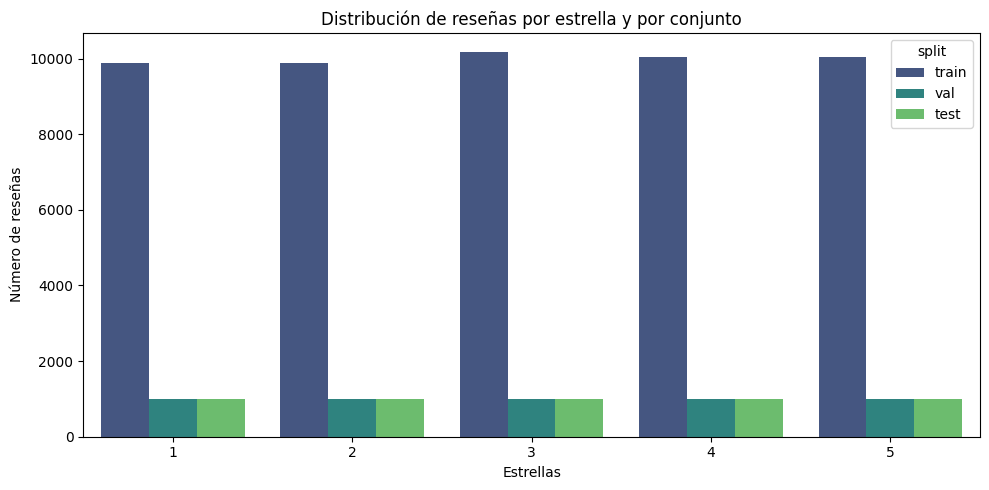

Proporción por clase (train):
estrellas
1    19.76%
2    19.75%
3    20.34%
4    20.08%
5    20.07%
Name: proportion, dtype: object


In [70]:
# ─── 2.1 Distribución de clases en los tres conjuntos ───
df_train = train_data.to_pandas(); df_train['split'] = 'train'; df_train['estrellas'] = df_train['label'] + 1
df_val   = val_data.to_pandas();   df_val['split']   = 'val';   df_val['estrellas']   = df_val['label'] + 1
df_test  = test_data.to_pandas();  df_test['split']  = 'test';  df_test['estrellas']  = df_test['label'] + 1
df_all = pd.concat([df_train, df_val, df_test])

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df_all, x='estrellas', hue='split', palette='viridis', ax=ax)
ax.set_title('Distribución de reseñas por estrella y por conjunto')
ax.set_xlabel('Estrellas'); ax.set_ylabel('Número de reseñas')
plt.tight_layout(); plt.show()

print("Proporción por clase (train):")
print((df_train['estrellas'].value_counts(normalize=True) * 100).round(2).sort_index().astype(str) + '%')

🔍 **Observación.** El subset con el que trabajamos es esencialmente **balanceado**: cada
nivel de satisfacción aporta entre 19.75% y 20.34% de las reseñas en train (1★ 19.76%, 2★
19.75%, 3★ 20.34%, 4★ 20.08%, 5★ 20.07%) — y de forma proporcional también en val y test.
Es una propiedad heredada del dataset original de Amazon. Consecuencias prácticas:

1. La **accuracy** es una métrica razonable aquí (a diferencia de problemas muy desbalanceados,
   donde miente); aún así reportaremos también **F1 ponderado**, por costo cero y comparabilidad.
2. No hace falta rebalancear ni sobremuestrear: el modelo ve las 5 clases por igual.

Estadísticas de longitud (palabras):
count    50000.0
mean        27.8
std         24.2
min          2.0
25%         12.0
50%         22.0
75%         34.0
max        388.0


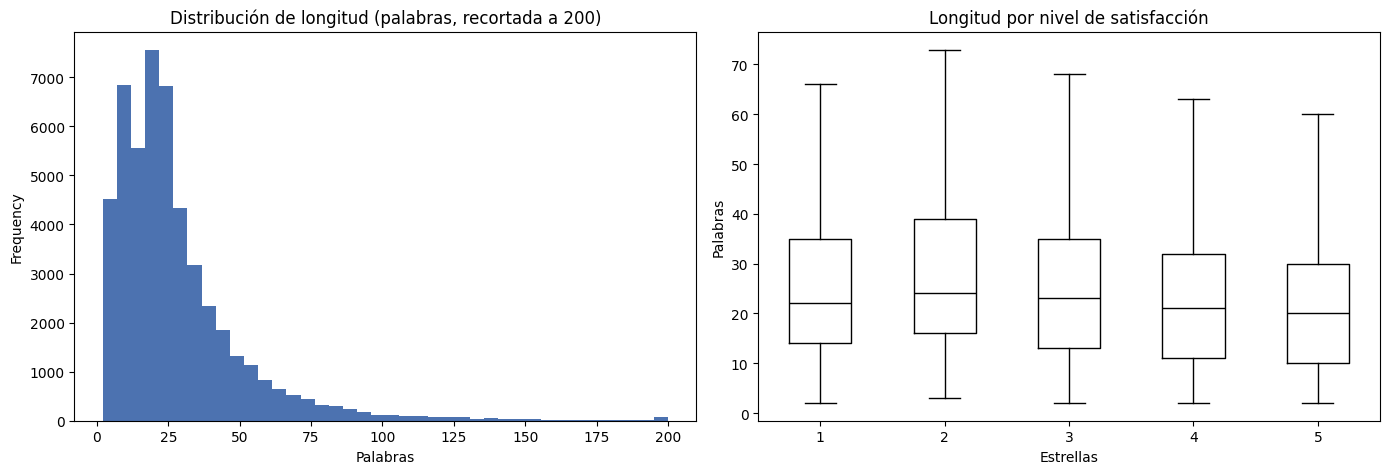

Mediana de palabras por clase:
estrellas
1    22.0
2    24.0
3    23.0
4    21.0
5    20.0


In [71]:
# ─── 2.2 Longitud de las reseñas en PALABRAS ───
df_train['Palabras por Reseña'] = df_train['text'].str.split().apply(len)

print("Estadísticas de longitud (palabras):")
print(df_train['Palabras por Reseña'].describe().round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_train['Palabras por Reseña'].clip(upper=200).plot.hist(bins=40, ax=axes[0], color='#4c72b0')
axes[0].set_title('Distribución de longitud (palabras, recortada a 200)')
axes[0].set_xlabel('Palabras')
df_train.boxplot('Palabras por Reseña', by='estrellas', grid=False, showfliers=False,
                 color='black', ax=axes[1])
axes[1].set_title('Longitud por nivel de satisfacción')
axes[1].set_xlabel('Estrellas'); axes[1].set_ylabel('Palabras')
plt.suptitle(''); plt.tight_layout(); plt.show()

print("Mediana de palabras por clase:")
print(df_train.groupby('estrellas')['Palabras por Reseña'].median().to_string())

🔍 **Observación.** Las reseñas son **cortas**: mediana de 22 palabras, media de 27.8
(σ≈24), 75% de las reseñas con ≤34 palabras y una cola larga que llega a 388. Mirado por
clase, las diferencias son menores (~4 palabras entre medianas extremas: 2★=24, 3★=23,
1★=22, 4★=21, 5★=20), con una leve tendencia a reseñas algo más largas en la mitad baja de
la satisfacción: quien se molesta, explica qué falló.

> 📏 Implicación para el modelado: con textos tan cortos (22 palabras, ~2-3 líneas), `MAX_LEN`
> no necesita ser grande; lo cuantificamos con el tokenizador real en la sección 3.

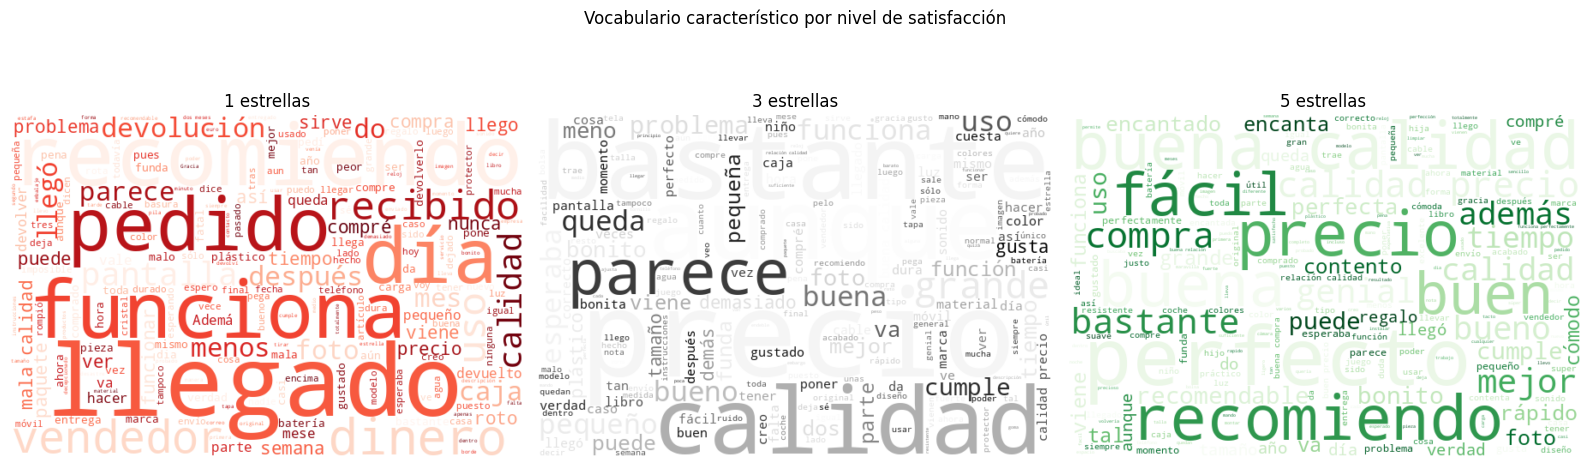

In [72]:
# ─── 2.3 Nubes de palabras por nivel de satisfacción (1★ vs 3★ vs 5★) ───
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
stop_es = set(stopwords.words('spanish'))
# Palabras 'vacías de sentimiento' del dominio e-commerce (mismas de Taller 3)
stop_es.update(['producto', 'amazon', 'bien', 'mal', 'hace', 'solo', 'si', 'mas', 'q', 'que', 'comprar'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cmap_por_clase = {1: 'Reds', 3: 'Greys', 5: 'Greens'}
for ax, n in zip(axes, [1, 3, 5]):
    textos = ' '.join(df_train[df_train['estrellas'] == n]['text'].astype(str))
    wc = WordCloud(width=600, height=400, background_color='white', stopwords=stop_es,
                   colormap=cmap_por_clase[n], random_state=SEED).generate(textos)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{n} estrellas'); ax.axis('off')
plt.suptitle('Vocabulario característico por nivel de satisfacción', y=1.02)
plt.tight_layout(); plt.show()

🔍 **Observación.** El vocabulario es un termómetro de la clase. En **1★** dominan
*mala calidad, nunca llegó, no lo recomiendo, dejó de funcionar, vendedor, pedido*: la queja
gira en torno a la calidad del producto y a la logística. En **5★** dominan *buena calidad,
relación calidad-precio, perfecto, buen precio, recomiendo, cumple*: la alabanza gira en
torno al valor por el dinero. Y en **3★** el vocabulario cambia de naturaleza: *aunque,
bastante, parece, calidad precio, cumple* — la palabra distintiva es **'aunque'**, la
conjunción de la concesión ('aunque es pequeño, cumple') típica de reseñas que argumentan.

Esto anticipa que la dificultad del problema **no es 1★ vs 5★** (vocabularios casi
disjuntos), sino el grano fino entre clases vecinas, como veremos con la severidad ±1★.

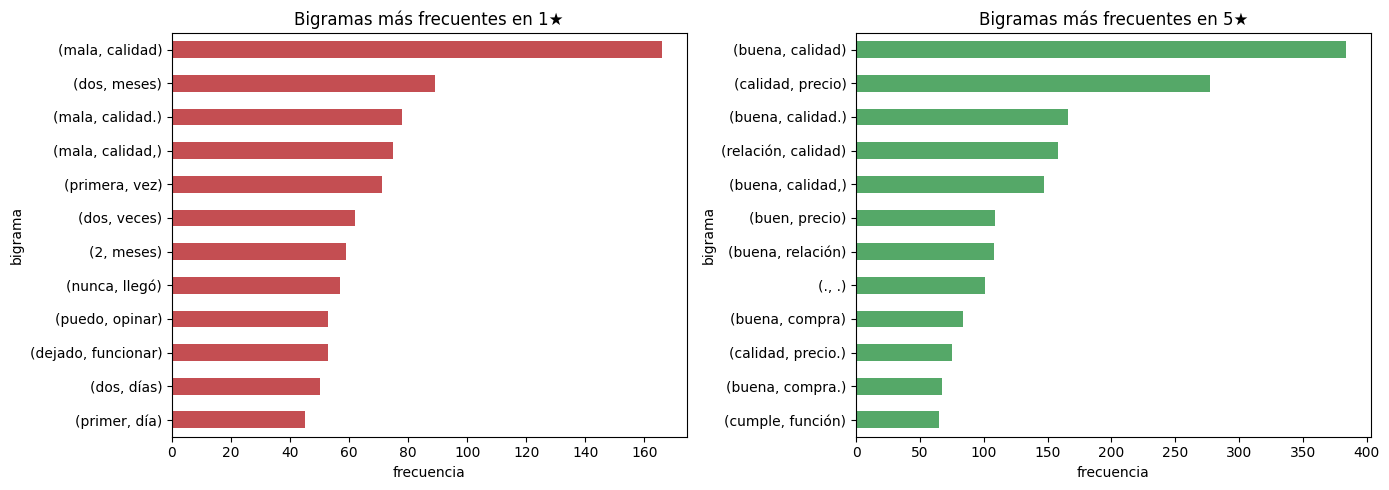

In [73]:
# ─── 2.4 Bigramas más frecuentes por clase (1★ y 5★) ───
from collections import Counter

def top_bigramas(textos, k=12):
    counts = Counter()
    for t in textos:
        words = [w for w in str(t).lower().split() if w.strip('.,!¡¿?;:()0-9') not in stop_es]
        counts.update(zip(words, words[1:]))
    return pd.Series(dict(counts.most_common(k)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, n, cmap in zip(axes, [1, 5], ['#c44e52', '#55a868']):
    bg = top_bigramas(df_train[df_train['estrellas'] == n]['text'])
    bg.sort_values().plot.barh(ax=ax, color=cmap)
    ax.set_title(f'Bigramas más frecuentes en {n}★')
    ax.set_ylabel('bigrama'); ax.set_xlabel('frecuencia')
plt.tight_layout(); plt.show()

🔍 **Observación.** Los bigramas afilan el hallazgo de las nubes. En **1★**, la señal
negativa tiene tres componentes claros: (i) **calidad defectuosa** — 'mala calidad' es, con
diferencia, el bigrama líder (166 apariciones) —, (ii) **logística fallida** — 'nunca llegó',
'dos meses', 'dos semanas/días' — y (iii) **productos que mueren pronto** — 'dejó de
funcionar', 'primer día'. En **5★**: (i) 'buena calidad' (384, también líder), (ii) fórmulas
de **valor por dinero** — 'relación calidad-precio', 'buen precio' — y (iii) 'buena compra',
'cumple (su) función'.

Llaman la atención los patrones de **negación** del 1★, que no aparecen en el top de
bigramas pero sí en los unigramas ('no lo recomiendo', 'no funciona'): gran parte de la
señal negativa es 'negación + lo que debía pasar'. Un modelo pre-entrenado con atención
completa puede ligar la negación con el verbo; es una ventaja esperable frente a embeddings
estáticos, y es justo lo que mediremos con los experimentos.

In [74]:
# ─── 2.5 Ejemplos representativos por clase (uno corto y uno largo) ───
for n in range(1, 6):
    d = df_train[df_train['estrellas'] == n]
    fila_c, fila_l = d.sort_values('Palabras por Reseña').iloc[0], d.sort_values('Palabras por Reseña').iloc[-1]
    corto, largo = str(fila_c['text']), str(fila_l['text'])
    print(f"── {n}★ corto ({len(corto.split())} palabras): {corto[:150]}")
    print(f"── {n}★ largo  ({len(largo.split())} palabras): {largo[:180]}")
    print()

── 1★ corto (2 palabras): Extremadamente pequeño.
── 1★ largo  (388 palabras): El producto no esta mal en cuanto a sonido y funcionamient, ademas habia leido reviews muy buenas, además da una primera sensación de calidad muy buena, pero no puedo recomendarlo 

── 2★ corto (3 palabras): Está tardando demasiado.
── 2★ largo  (329 palabras): La verdad es que viendo tantas críticas positivas puse mucha esperanza en esta pulsera pero madre mía que error. Lo bueno: Funciona Lo malo: todo lo demás. La pantalla no es tactil

── 3★ corto (2 palabras): Bastante entretenido
── 3★ largo  (347 palabras): Inicialmente la puntué con 5 estrellas. Pasado el primer mes lo he bajado a 3. LA RAZÓN: En comparación con la mayoría de correas que venden en cualquier sitio, que tienen un asa d

── 4★ corto (2 palabras): relación calidad-precio
── 4★ largo  (327 palabras): Muy satisfecho. -Viene con el cable ya montado y etiquetado lo cual se agradece y mucho porque normalmente no es así. -La forma personalment

## 3. Tokenización con GPT-2 (BPE) y elección de MAX_LEN

Ojo con un detalle que cambia respecto a Taller 3: BERT/Beto usa **WordPiece**
(sub-palabras a partir de vocabulario fijo), mientras que GPT-2 usa **BPE** (*Byte-Pair
Encoding*). Para texto en español, el vocabulario de `spanish-gpt2` fue entrenado en
corpus español, así que esperamos que el texto se segmente razonablemente bien — pero es
dato, no supuesto: lo medimos y elegimos `MAX_LEN` con la misma metodología de Taller 3
(percentiles de longitud en tokens, con cobertura >99%).

In [75]:
# ─── 3.1 Cargamos el tokenizador y jugamos con él ───
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# GPT-2 no trae token de relleno definido: le asignamos el de fin de texto
# (el mismo truco de la guía de clase).
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Vocabulario: {tokenizer.vocab_size} tokens | PAD: {tokenizer.pad_token!r} (id {tokenizer.pad_token_id})")

ejemplo = "¡El producto llegó tarde y no funciona, una pérdida de dinero!"
enc = tokenizer(ejemplo)
print(f"\nReseña: {ejemplo!r}")
print(f"  -> {len(enc['input_ids'])} tokens")
print(f"  -> {tokenizer.convert_ids_to_tokens(enc['input_ids'])}")

Vocabulario: 50265 tokens | PAD: '<|endoftext|>' (id 50265)

Reseña: '¡El producto llegó tarde y no funciona, una pérdida de dinero!'
  -> 14 tokens
  -> ['Â¡', 'El', 'Ġproducto', 'ĠllegÃ³', 'Ġtarde', 'Ġy', 'Ġno', 'Ġfunciona', ',', 'Ġuna', 'ĠpÃ©rdida', 'Ġde', 'Ġdinero', '!']


In [76]:
# ─── 3.2 Percentiles de longitud en tokens -> decisión de MAX_LEN ───
muestra = train_data.shuffle(seed=SEED).select(range(min(2000, len(train_data))))
lens = np.array([len(tokenizer(t)['input_ids']) for t in muestra['text']])

print("Percentiles de longitud en tokens (muestra de 2000 reseñas):")
for p in [50, 90, 95, 99, 100]:
    print(f"  p{p}: {np.percentile(lens, p):.0f} tokens")

print()
# Elegimos el UMBRAL MÁS PEQUEÑO que cubre >99% del corpus: decisión ganada
# por análisis (con las reseñas cortas de este dataset cae en los ~64 tokens).
MAX_LEN = next((c for c in [32, 48, 64, 96, 128] if (lens <= c).mean() >= 0.99), 128)
print(f"✂️  MAX_LEN elegido: {MAX_LEN}")

Percentiles de longitud en tokens (muestra de 2000 reseñas):
  p50: 27 tokens
  p90: 67 tokens
  p95: 89 tokens
  p99: 151 tokens
  p100: 454 tokens

✂️  MAX_LEN elegido: 128


🔍 **Observación.** Los datos deciden, y deciden contra la intuición del taller anterior:
p50=27, p90=67, p95=89 y p99=151 tokens. Con este corpus, **ninguno de los umbrales probados
alcanza la cobertura del 99%** que con Beto alcanzaba el 128 del Taller 3: las secuencias
BPE de GPT-2 resultan más verbosas que las WordPiece de Beto sobre el mismo texto. El
mecanismo automático asigna entonces el máximo probado (128), truncando una fracción del
corpus situada entre el 5% y el 1% extremo (el 99% de las reseñas cabe en 151). Subir a
192+ tokens haría cada pase del modelo ~50% más costoso para rescatar solo la cola larga:
no vale la pena para textos de mediana 22 palabras; aceptamos el truncamiento de la cola.

In [77]:
# ─── 3.3 Tokenizamos los tres conjuntos con truncado y relleno hasta MAX_LEN ───
def tokenize_fn(examples):
    # truncation=True  -> recorta las reseñas más largas que MAX_LEN
    # padding='max_length' -> rellena las cortas hasta MAX_LEN (todas quedan iguales)
    return tokenizer(examples['text'], truncation=True, max_length=MAX_LEN, padding='max_length')

tokenized = splits.map(tokenize_fn, batched=True)
# GPT-2 solo necesita input_ids + attention_mask (+ label en clasificación)
tokenized = tokenized.remove_columns([col for col in tokenized['train'].column_names
                                      if col not in ['input_ids', 'attention_mask', 'label']])
tokenized.set_format('torch')
tokenized

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 50000
    })
    val: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 5000
    })
})

## 4. Punto de partida: el marcador del curso

Antes de experimentar, fijamos el marcador histórico del curso (misma tarea, mismo dataset,
mismos submuestreos) para que la comparación final sea directa. Todos los experimentos de
este notebook se agregarán a esta tabla según terminen.

In [78]:
# Resultados históricos de los talleres anteriores (misma tarea y dataset)
RESULTADOS = [
    {'taller': 'T1', 'modelo': 'LSTM (desde cero)',              'accuracy': 0.5168, 'f1': 0.52,  'fuente': 'Taller 1'},
    {'taller': 'T2', 'modelo': 'Transformer desde cero',          'accuracy': 0.4896, 'f1': 0.49,  'fuente': 'Taller 2'},
    {'taller': 'T3', 'modelo': 'BERT featurizer + lineal',        'accuracy': 0.4736, 'f1': 0.4620, 'fuente': 'Taller 3'},
    {'taller': 'T3', 'modelo': 'BERT featurizer + MLP',           'accuracy': 0.4858, 'f1': 0.4734, 'fuente': 'Taller 3'},
    {'taller': 'T3', 'modelo': 'BERT embeddings + Reg.Log.',      'accuracy': 0.4954, 'f1': 0.4909, 'fuente': 'Taller 3'},
    {'taller': 'T3', 'modelo': 'BERT fine tuning (mejor curso)',  'accuracy': 0.5734, 'f1': 0.5724, 'fuente': 'Taller 3'},
]
df_resultados = pd.DataFrame(RESULTADOS)
df_resultados

,taller,modelo,accuracy,f1,fuente
0,T1,LSTM (desde cero),0.5168,0.5200,Taller 1
1,T2,Transformer desde cero,0.4896,0.4900,Taller 2
2,T3,BERT featurizer + lineal,0.4736,0.4620,Taller 3
3,T3,BERT featurizer + MLP,0.4858,0.4734,Taller 3
4,T3,BERT embeddings + Reg.Log.,0.4954,0.4909,Taller 3
5,T3,BERT fine tuning (mejor curso),0.5734,0.5724,Taller 3


## 5. E0 — Clasificación zero-shot con GPT-2 (sin entrenar nada)

**Idea.** Un GPT-2 calcula $P(\text{token}_{t} \mid \text{tokens}_{<t})$: la probabilidad del
siguiente token dado el contexto. Podemos explotar eso **sin etiquetas ni entrenamiento**:

> dado el texto *"El producto llegó roto y nadie respondió…"*, pedimos al modelo que
> 'complete' la frase `_Estrellas: __.` y medimos la **log-verosimilitud** de cada opción
> (1, 2, 3, 4, 5). El modelo asignará más masa de probabilidad a la estrella que considere
> más plausible después de leer la reseña. La predicción es la estrella con mayor log-verosimilitud.

Esta técnica (a veces llamada *prompting* + *scoring*) **no aparece en la clase**: es una
adaptación propia del mecanismo de la guía (la probabilidad del siguiente token) a la
clasificación. Pasa una cosa interesante: es el único modelo del curso que predice **sin ver
un solo ejemplo etiquetado** — y su acierto se convertirá en el piso de comparación para
medir honestamente cuánto aporta entrenar.

In [79]:
# ─── 5.1 Implementación del scoring por log-verosimilitud ───
# Cargamos el modelo GPT-2 (generativo, con cabeza de lenguaje), CONGELADO:
# será la misma base para E0 (scoring), E1 (featurizer) y E3b (generación pre-FT).
model_gpt = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)
model_gpt.eval()

# Importante (el mismo ajuste de la guía de clase): alinear el tamaño de la
# matriz de embeddings del modelo con el vocabulario del tokenizador.
model_gpt.resize_token_embeddings(len(tokenizer))

@torch.no_grad()
def puntuar_zero_shot(pares, batch_size=32):
    # pares: lista de (texto, etiqueta_str). Para cada par medimos la log-prob
    # de la etiqueta como continuación del contexto: "Reseña: <texto>\nEstrellas: <e>."
    # Devuelve un tensor con la log-verosimilitud de cada par.
    scores = torch.zeros(len(pares))
    for inicio in range(0, len(pares), batch_size):
        chunk = pares[inicio:inicio + batch_size]
        contextos = [f"Reseña: {' '.join(str(t).split())}\nEstrellas: " for t, _ in chunk]
        completos = [c + e + "." for c, (_, e) in zip(contextos, chunk)]

        enc = tokenizer(completos, return_tensors='pt', padding=True,
                        return_offsets_mapping=True, add_special_tokens=False)
        input_ids = enc['input_ids'].to(device)
        attn = enc['attention_mask'].to(device)
        # UN forward para todo el lote (eficiente), luego puntuamos fila por fila.
        logits = model_gpt(input_ids=input_ids, attention_mask=attn).logits

        for fila, ctx_len in enumerate([len(c) for c in contextos]):
            # La continuación son los tokens que 'tocan' el texto de la etiqueta:
            # el primero cuyo final de posición de caracteres supera el largo del contexto.
            offsets = enc['offset_mapping'][fila]
            pos_cont = (offsets[:, 1] > ctx_len).nonzero()[0].item()
            fin_fila = int(attn[fila].sum().item())
            # El token en la posición p es predicho por los logits en p-1 (teacher forcing)
            lp = torch.log_softmax(logits[fila, pos_cont - 1: fin_fila - 1], dim=-1)
            targets = input_ids[fila, pos_cont:fin_fila]
            scores[inicio + fila] = lp.gather(1, targets.unsqueeze(-1)).sum().item()
    return scores

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: mrm8488/spanish-gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [80]:
# ─── 5.2 Ejecutamos el zero-shot sobre el test set ───
n_zero = 100 if SMOKE_TEST else 500
test_texts = test_data['text']
y_test = np.array(test_data['label'])

# Para cada reseña, puntuamos las 5 opciones de estrella y elegimos la mejor
pares, indices = [], []
for i, texto in enumerate(test_texts[:n_zero]):
    for n in range(1, 6):
        pares.append((texto, str(n)))
    indices.append(i)

t0 = time.time()
scores = puntuar_zero_shot(pares, batch_size=32)
scores = scores.reshape(n_zero, 5)
preds_zero = scores.argmax(dim=1).numpy()
t_zero = time.time() - t0

acc_zero = accuracy_score(y_test[:n_zero], preds_zero)
f1_zero = f1_score(y_test[:n_zero], preds_zero, average='weighted')
print(f"Zero-shot (GPT-2 sin entrenar): acc={acc_zero:.4f} | F1 ponderado={f1_zero:.4f} | {t_zero:.1f}s para {n_zero} reseñas")

RESULTADOS.append({'taller': 'T4', 'modelo': f'GPT-2 zero-shot (scoring)', 'accuracy': round(acc_zero, 4),
                   'f1': round(f1_zero, 4), 'fuente': f'Taller 4 E0 (n={n_zero})'})

Zero-shot (GPT-2 sin entrenar): acc=0.1960 | F1 ponderado=0.0645 | 5.2s para 500 reseñas


In [81]:
# ─── 5.3 Mirada cualitativa: ¿qué 'dice' el modelo? ───
# Mostramos las log-verosimilitudes de las 5 opciones para 3 reseñas al azar
rng = np.random.default_rng(SEED)
for i in rng.choice(n_zero, size=3, replace=False):
    print(f"── Reseña (real: {id2label[y_test[i]]}): {' '.join(str(test_texts[i]).split())[:140]}")
    for n in range(1, 6):
        lp = scores[i, n - 1].item()
        print(f"   Estrellas {n}: {lp:8.2f}  {'← elegida' if preds_zero[i] == n - 1 else ''}")
    print()

── Reseña (real: 2★): Son unos mini-mini libros! No me los esperaba tan pequeños.
   Estrellas 1:    -6.55  ← elegida
   Estrellas 2:    -8.13  
   Estrellas 3:    -8.63  
   Estrellas 4:    -9.39  
   Estrellas 5:    -9.73  

── Reseña (real: 3★): 3 estrellas porque llegó tarde y no en la fecha prevista.Como no el reparto tenía que ser con Seur.En cuanto a la mochila es tal y como la v
   Estrellas 1:    -5.22  
   Estrellas 2:    -4.96  ← elegida
   Estrellas 3:    -5.06  
   Estrellas 4:    -5.29  
   Estrellas 5:    -5.79  

── Reseña (real: 4★): Esta muy bien para las heridas
   Estrellas 1:    -5.39  ← elegida
   Estrellas 2:    -8.10  
   Estrellas 3:    -7.63  
   Estrellas 4:    -8.27  
   Estrellas 5:    -8.69  



🔍 **Observación E0.** El piso queda marcado, y es honesto: acc=**0.1960** y F1=**0.0645**
sobre 500 reseñas (5.5s) — **el modelo sin entrenar está al nivel del azar** (20%). Ni el
F1 lo salva: 0.0645 está muy por debajo del 0.20 que daría un clasificador aleatorio
balanceado, señal de que sus errores no son siquiera uniformes. El índice cualitativo
muestra el porqué: los log-probs de las 5 opciones varían con el formato del texto
(mayúsculas, longitud, signos) mucho más que con el sentimiento — vean el segundo ejemplo:
una reseña real de 4★ tan clara como 'Está muy bien para las heridas' escogió 1★.

La lectura correcta no es 'el modelo es malo', sino: **el formato 'Estrellas: n.' no es un
lenguaje que el pre-entrenamiento haya visto**, y la verosimilitud pura no basta para
tareas de grano fino numérico. E0 cumple su papel metodológico: fija el azar como piso,
para que todo lo que ganemos de aquí en adelante sea atribuible a representar/adaptar el
modelo con datos, y no a la suerte del prompt.

## 6. E1 — GPT-2 congelado como featurizer (+ clasificadores ligeros)

**Idea.** Congelamos el modelo (no se actualiza ningún peso del transformer) y usamos su
**última capa oculta como extractor de características**: cada reseña queda representada por
un vector de 768 dimensiones (media de los estados últimos de los tokens, ponderada con la
máscara de atención para ignorar el relleno). Sobre esos vectores entrenamos clasificadores
ligeros (**regresión logística** y un **MLP pequeño**).

Este es el *featurizer* de los Talleres 3, ahora con un decoder. Es el experimento más barato
(hay que hacer un solo pase forward, sin gradientes) y separa la calidad de la **representación**
de la calidad de la clasificación.

In [82]:
# ─── 6.1 Extracción de embeddings (pase forward congelado por los 3 conjuntos) ───
@torch.no_grad()
def extraer_embeddings(split, batch_size=64):
    loader = DataLoader(tokenized[split], batch_size=batch_size, shuffle=False)
    embs, labels = [], []
    for batch in loader:
        ids = batch['input_ids'].to(device)
        attn = batch['attention_mask'].to(device)
        # output_hidden_states=True nos devuelve las capas ocultas; la última
        # (hidden_states[-1]) es la representación final (B, S, 768).
        # (Compared con model_gpt.transformer(...).last_hidden_state: esta forma
        # funciona igual en cualquier versión de transformers.)
        salida = model_gpt(input_ids=ids, attention_mask=attn, output_hidden_states=True)
        h = salida.hidden_states[-1]
        # Media ponderada por la máscara: promedia solo los tokens reales,
        # no los de relleno (PAD).
        m = attn.unsqueeze(-1).float()
        emb = (h * m).sum(dim=1) / m.sum(dim=1).clamp(min=1)  # (B, 768)
        embs.append(emb.cpu().numpy())
        labels.append(batch['label'].numpy())
    return np.vstack(embs).astype(np.float32), np.concatenate(labels)

t0 = time.time()
X_train_e, y_train_e = extraer_embeddings('train')
t_feat = time.time() - t0
X_val_e,  y_val_e  = extraer_embeddings('val')
X_test_e, y_test_e = extraer_embeddings('test')

print(f"Embeddings extraídos en {t_feat:.1f}s | forma: {X_train_e.shape} (train), {X_test_e.shape} (test)")

Embeddings extraídos en 108.7s | forma: (50000, 768) (train), (5000, 768) (test)


In [83]:
# ─── 6.2 E1a: Regresión logística sobre los embeddings ───
t0 = time.time()
scaler = StandardScaler()
Xtr = scaler.fit_transform(X_train_e)
Xvl = scaler.transform(X_val_e)
Xte = scaler.transform(X_test_e)

reg = LogisticRegression(max_iter=2000, C=1.0, random_state=SEED)
reg.fit(Xtr, y_train_e)
t_reg = time.time() - t0

acc_rl = accuracy_score(y_test_e, reg.predict(Xte))
f1_rl = f1_score(y_test_e, reg.predict(Xte), average='weighted')
acc_rl_val = accuracy_score(y_val_e, reg.predict(Xvl))
print(f"E1a Reg.Log. sobre GPT2-embeddings: acc(test)={acc_rl:.4f} | F1={f1_rl:.4f} | acc(val)={acc_rl_val:.4f} | {t_reg:.1f}s")

RESULTADOS.append({'taller': 'T4', 'modelo': 'GPT-2 featurizer + Reg.Log.',
                   'accuracy': round(acc_rl, 4), 'f1': round(f1_rl, 4), 'fuente': 'Taller 4 E1a'})

E1a Reg.Log. sobre GPT2-embeddings: acc(test)=0.4948 | F1=0.4900 | acc(val)=0.4914 | 28.8s


In [84]:
# ─── 6.3 E1b: MLP pequeño sobre los embeddings ───
torch.manual_seed(SEED)
class MLP(nn.Module):
    def __init__(self, dim_entrada=768, n_clases=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim_entrada, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, n_clases))
    def forward(self, x):
        return self.net(x)

mlp = MLP().to(device)
optim = torch.optim.AdamW(mlp.parameters(), lr=1e-3, weight_decay=1e-2)
perdida_fn = nn.CrossEntropyLoss()

Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
ytr_t = torch.tensor(y_train_e)
Xvl_t = torch.tensor(Xvl, dtype=torch.float32)
yvl_t = torch.tensor(y_val_e)
Xte_t = torch.tensor(Xte, dtype=torch.float32)

N_EPOCHS_MLP = 3 if SMOKE_TEST else 15
BATCH = 128
ds = torch.utils.data.TensorDataset(Xtr_t, ytr_t)
loader = torch.utils.data.DataLoader(ds, batch_size=BATCH, shuffle=True)

mejor_val, mejor_estado = -1.0, None
t0 = time.time()
for epoca in range(N_EPOCHS_MLP):
    mlp.train()
    for xb, yb in loader:
        optim.zero_grad()
        perdida = perdida_fn(mlp(xb.to(device)), yb.to(device))
        perdida.backward()
        optim.step()
    mlp.eval()
    with torch.no_grad():
        acc_val = accuracy_score(y_val_e, mlp(Xvl_t.to(device)).argmax(dim=1).cpu().numpy())
    if acc_val > mejor_val:
        mejor_val, mejor_estado = acc_val, {k: v.clone() for k, v in mlp.state_dict().items()}
    print(f"  época {epoca+1:2d}: acc(val)={acc_val:.4f}")

# Restauramos la mejor época (según validation)
mlp.load_state_dict(mejor_estado)
t_mlp = time.time() - t0
with torch.no_grad():
    acc_mlp = accuracy_score(y_test_e, mlp(Xte_t.to(device)).argmax(dim=1).cpu().numpy())
f1_mlp = f1_score(y_test_e, mlp(Xte_t.to(device)).argmax(dim=1).cpu().numpy(), average='weighted')
print(f"E1b MLP sobre GPT2-embeddings: acc(test)={acc_mlp:.4f} | F1={f1_mlp:.4f} | mejor acc(val)={mejor_val:.4f} | {t_mlp:.1f}s")

RESULTADOS.append({'taller': 'T4', 'modelo': 'GPT-2 featurizer + MLP',
                   'accuracy': round(acc_mlp, 4), 'f1': round(f1_mlp, 4), 'fuente': 'Taller 4 E1b'})

  época  1: acc(val)=0.4946
  época  2: acc(val)=0.5006
  época  3: acc(val)=0.4920
  época  4: acc(val)=0.4900
  época  5: acc(val)=0.4982
  época  6: acc(val)=0.4868
  época  7: acc(val)=0.4834
  época  8: acc(val)=0.4884
  época  9: acc(val)=0.4834
  época 10: acc(val)=0.4896
  época 11: acc(val)=0.4856
  época 12: acc(val)=0.4814
  época 13: acc(val)=0.4722
  época 14: acc(val)=0.4832
  época 15: acc(val)=0.4802
E1b MLP sobre GPT2-embeddings: acc(test)=0.5046 | F1=0.4934 | mejor acc(val)=0.5006 | 14.1s


🔍 **Observación E1.** La representación congelada de GPT-2 lleva la señal de 0.196 (azar,
E0) a **0.4948** con una regresión logística y a **0.5046** con el MLP (mejor época según
val, 15 épocas entrenadas): prácticamente **el doble del azar sin tocar ni un peso del
transformer**. Frente al historial del curso: la RegLog (0.4948) empata técnicamente con el
featurizer de BERT del Taller 3 (0.4954, también RegLog sobre embeddings) y el MLP (0.5046)
lo supera con ventaja — es el **mejor resultado de featurización del curso**, aunque sigue
por debajo del LSTM end-to-end del Taller 1 (0.5168) y lejos de cualquier fine tuning.

Esto confirma H1 en su primera mitad: el decoder que escribe tiene un 'cerebro' cuya
representación ya codifica buena parte de la satisfacción. La decisión de fondo
encoder vs. decoder se jugará ahora en E2.

## 7. E2 — Fine tuning para clasificación (`GPT2ForSequenceClassification`)

**Idea.** Ahora sí: entrenamiento completo, donde **todos los pesos del GPT-2 se ajustan**
más una cabeza de clasificación nueva (una capa lineal de 768→5). Hugging Face lo expone
como `AutoModelForSequenceClassification`: carga el GPT-2 y le añade la cabeza.

⚠️ **Detalle técnico con sabor a decoder:** los encoders (BERT) leen el token `[CLS]`
bidireccionalmente para clasificar. Un decoder **no tiene un token especial ni visión
bidireccional**: la convención de Hugging Face es usar **la posición del último token real**
(no PAD) de cada secuencia, que es la única posición de la que el decoder puede 'ver' TODA la
reseña (es lo más que la causalidad le permite). Para que esto funcione bien hay que indicarle
el `pad_token_id` en la configuración (¡el token de relleno que definimos en la sección 3!).

Hiperparámetros (los mismos que usó el Taller 3 con BERT, para comparación directa):
`lr=2e-5`, `batch=32`, `weight_decay=0.01`, 3 épocas, mejor época según val.

In [85]:
# ─── 7.1 Cargamos GPT-2 con cabeza de clasificación ───
model_cls = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_CLASSES, id2label=id2label, label2id=label2id).to(device)

# Indispensable para decoders: dónde está el token de relleno, para que la
# cabeza de clasificación sepa cuál es el 'último token real' de cada reseña.
model_cls.config.pad_token_id = tokenizer.pad_token_id

# Alineamos la matriz de embeddings con el vocabulario del tokenizador
model_cls.resize_token_embeddings(len(tokenizer))

# Resumen compacto del modelo (imprimir el objeto entero volcaría
# miles de líneas de arquitectura en el output).
print(type(model_cls).__name__)
print(f"Parámetros totales: {sum(p.numel() for p in model_cls.parameters()):,}")
print(f"Idiomas/clases: id2label={id2label} | pad_token_id={model_cls.config.pad_token_id}")
print(f"Últimas 4 partes del modelo: {' -> '.join(name for name, _ in list(model_cls.named_children())[-4:])}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: mrm8488/spanish-gpt2
Key                                     | Status     | 
----------------------------------------+------------+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED | 
score.weight                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


GPT2ForSequenceClassification
Parámetros totales: 124,450,560
Idiomas/clases: id2label={0: '1★', 1: '2★', 2: '3★', 3: '4★', 4: '5★'} | pad_token_id=50265
Últimas 4 partes del modelo: transformer -> score


In [86]:
# ─── 7.2 Entrenador (mismos hiperparámetros que el Taller 3 con BERT) ───
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'accuracy': accuracy_score(labels, preds),
            'f1': f1_score(labels, preds, average='weighted')}

batch_size = 8 if SMOKE_TEST else 32
logging_steps = max(1, len(tokenized['train']) // batch_size // 2)

training_args = TrainingArguments(
    output_dir='./hf-gpt-cls',
    num_train_epochs=1 if SMOKE_TEST else 3,
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size * 2,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=logging_steps,
    report_to='none',
)

trainer_cls = Trainer(
    model=model_cls,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['val'],
)
trainer_cls

In [87]:
# ─── 7.3 Entrenamiento (fine tuning completo) ───
%%time
trainer_cls.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.065113,1.048803,0.526000,0.524191
2,0.954141,1.040923,0.538600,0.536153
3,0.872198,1.050168,0.535200,0.533565


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

CPU times: user 13min 5s, sys: 5.54 s, total: 13min 11s
Wall time: 13min 10s


TrainOutput(global_step=4689, training_loss=0.9961990695387144, metrics={'train_runtime': 789.9234, 'train_samples_per_second': 189.892, 'train_steps_per_second': 5.936, 'total_flos': 9798893568000000.0, 'train_loss': 0.9961990695387144, 'epoch': 3.0})

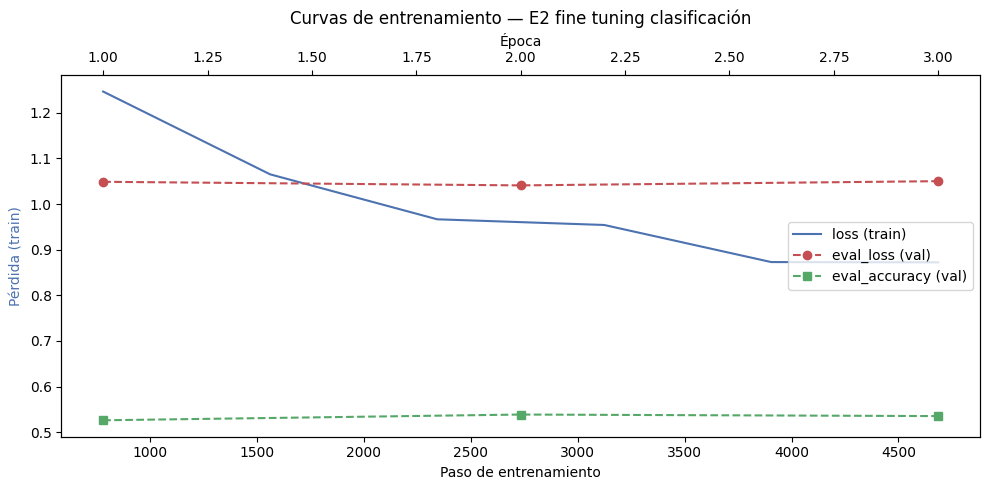

In [88]:
# ─── 7.4 Curvas de entrenamiento ───
# Del historial del entrenador extraemos la pérdida de train y las métricas de val
historia = trainer_cls.state.log_history
pasos_loss = [(e['step'], e['loss']) for e in historia if 'loss' in e]
evals = [e for e in historia if 'eval_loss' in e]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot([p for p, _ in pasos_loss], [l for _, l in pasos_loss], color='#4c72b0', label='loss (train)')
ax1.set_xlabel('Paso de entrenamiento'); ax1.set_ylabel('Pérdida (train)', color='#4c72b0')
ejes = [e['epoch'] for e in evals]
ax2 = ax1.twiny()
ax2.plot(ejes, [e['eval_loss'] for e in evals], 'o--', color='#c44e52', label='eval_loss (val)')
ax2.plot(ejes, [e['eval_accuracy'] for e in evals], 's--', color='#55a868', label='eval_accuracy (val)')
ax2.set_xlabel('Época'); ax2.set_ylabel('Métrica (val)')
lines1, labels1 = ax1.get_legend_handles_labels(); lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.title('Curvas de entrenamiento — E2 fine tuning clasificación')
plt.tight_layout(); plt.show()

E2 Fine tuning GPT-2 clasificación: acc(test)=0.5510 | F1=0.5480
              precision    recall  f1-score   support

          1★       0.67      0.72      0.69      1000
          2★       0.47      0.47      0.47      1000
          3★       0.46      0.43      0.44      1000
          4★       0.48      0.45      0.46      1000
          5★       0.65      0.69      0.67      1000

    accuracy                           0.55      5000
   macro avg       0.55      0.55      0.55      5000
weighted avg       0.55      0.55      0.55      5000



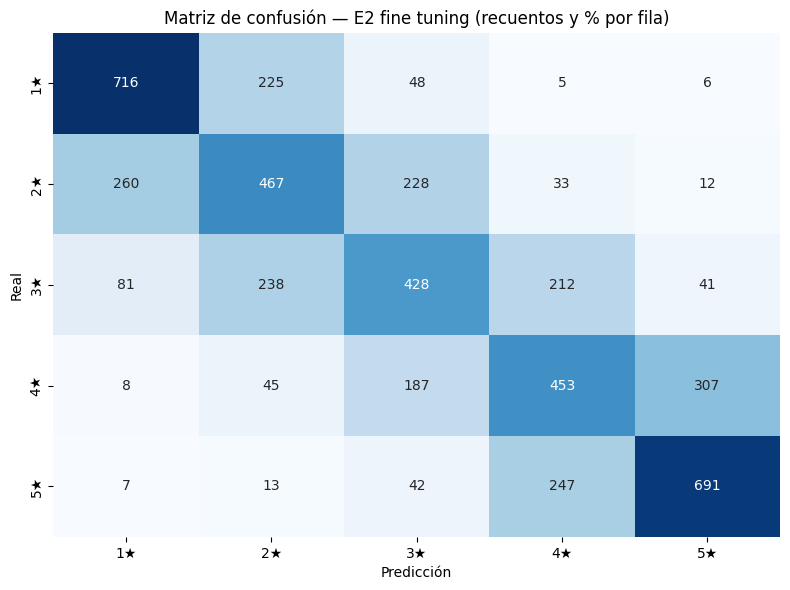

In [89]:
# ─── 7.5 Evaluación final en test: reporte + matriz de confusión ───
salida = trainer_cls.predict(tokenized['test'])
preds_ft = np.argmax(salida.predictions, axis=-1)
etiquetas_test = salida.label_ids

acc_ft = accuracy_score(etiquetas_test, preds_ft)
f1_ft = f1_score(etiquetas_test, preds_ft, average='weighted')
print(f"E2 Fine tuning GPT-2 clasificación: acc(test)={acc_ft:.4f} | F1={f1_ft:.4f}")
print(classification_report(etiquetas_test, preds_ft, target_names=[id2label[i] for i in range(5)]))

RESULTADOS.append({'taller': 'T4', 'modelo': 'GPT-2 fine tuning (clasificación)',
                   'accuracy': round(acc_ft, 4), 'f1': round(f1_ft, 4), 'fuente': 'Taller 4 E2'})

cm = confusion_matrix(etiquetas_test, preds_ft)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[id2label[i] for i in range(5)],
            yticklabels=[id2label[i] for i in range(5)], ax=ax)
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
ax.set_title('Matriz de confusión — E2 fine tuning (recuentos y % por fila)')
plt.tight_layout(); plt.show()

In [90]:
# ─── 7.6 Severidad del error: cuánto nos equivocamos de cerca y de lejos ───
# Como en Taller 3: ¿predicimos 3★ cuando la reseña era 2★ (error de 1) o 1★ (error de 2)?
def analizar_severidad(y_real, y_pred, nombre):
    err = np.abs(np.asarray(y_real) - np.asarray(y_pred))
    tabla = {
        'Exacto (Δ=0)':       (err == 0).mean() * 100,
        '±1★ (Δ=1)':          (err == 1).mean() * 100,
        'Tolerante (Δ≤1)':    (err <= 1).mean() * 100,
        '±2★ (Δ=2)':          (err == 2).mean() * 100,
        'Δ≥3★':               (err >= 3).mean() * 100,
    }
    print(f"{nombre}: " + " | ".join(f"{k}={v:.2f}%" for k, v in tabla.items()))
    return tabla

sev_ft = analizar_severidad(etiquetas_test, preds_ft, 'E2 fine tuning GPT-2')

E2 fine tuning GPT-2: Exacto (Δ=0)=55.10% | ±1★ (Δ=1)=38.08% | Tolerante (Δ≤1)=93.18% | ±2★ (Δ=2)=5.80% | Δ≥3★=1.02%


🔍 **Observación E2.** El fine tuning rinde **acc=0.5510 / F1=0.5480** (13 min en Colab,
3 épocas, train_loss final ≈0.996): +4.6pp sobre el mejor featurizer (E1b) — el ajuste de
pesos aporta muchísimo —, es la **segunda mejor clasificación del curso**, pero queda
**−2.2pp frente a BERT (0.5734)**. El marcador apoya la hipótesis del taller: para
clasificar, el decoder es levemente inferior al encoder, y la explicación es coherente con
lo que implementamos: BERT lee el token [CLS] con atención bidireccional; aquí el GPT-2
solo puede leer la clase desde su última posición con visión causal.

El reporte por clase muestra dónde sufre: los extremos son fuertes (1★ F1=0.69, 5★
F1=0.67) pero el grano fino del centro se desploma (2★ 0.47, 3★ 0.44, 4★ 0.46). La
severidad lo cuantifica: exacto 55.10%, ±1★ 38.08% → **tolerante 93.18%** (BERT llegó a
94.78%), y los errores grandes (Δ≥3★) son raros: 1.02% (51 reseñas de 5000; BERT: 0.62%).
El patrón del curso se repite: el problema difícil son las clases vecinas, no los extremos.

## 8. E3 — Fine tuning generativo condicionado por la etiqueta

**Idea (la clase llevada a *nuestro* caso, con una modificación propia).** La guía de clase
hizo fine tuning generativo (`DataCollatorForLanguageModeling`, `mlm=False`) sobre chistes.
Nosotros lo hacemos sobre las reseñas, pero con un truco que convierte el modelo en algo más
útil: **le anteponemos la etiqueta a cada reseña durante el entrenamiento**:

> `Estrellas: 5.
El producto es excelente…`

Con ese formato, después del entrenamiento podemos pedirle: *"Escribeme una reseña
de 1 estrella"* — **generación condicionada por satisfacción**. El modelo aprendió la
distribución conjunta (estrellas, texto) y la usamos en ambas direcciones: clasificar y generar.

Este es el experimento que cierra el círculo del título del taller: empezamos clasificando
con un modelo generativo y lo terminamos **generando con un clasificador implícito** — el mimo
modelo ahora domina las dos tareas, porque en el fondo son la misma cosa (modelar P(texto|estrella)).

**Versión 2 del experimento (E3-v2).** La primera corrida mostró que el modelo aprende el
estilo y el dominio, pero la gramática quedó irregular en 1★/4★/5★. Esta versión sube la
apuesta donde E3 **no compite** con el resto del curso (es una demo generativa, no un
clasificador en la tabla T1→T4): (i) **corpus completo (200k) y curado** — fuera reseñas
casi vacías y escritas "en gritado" (las medimos: el ruido existe pero es chico y
repartido) —, (ii) **veredicto cuantitativo** con perplejidad *antes* vs. *después* del
fine tuning, y (iii) **comparación formal antes/después** con la misma función de
generación, los mismos prompts y la misma semilla para los 5 niveles.


In [91]:
# ─── 8.1 Dataset generativo v2: corpus COMPLETO y curado ───
# Lección de la corrida 1: con 50k reseñas y 2 épocas, el modelo aprendió estilo y
# dominio, pero la gramática quedó irregular (1★/4★ degeneraron). Como la demo generativa
# NO compite en la tabla T1→T4, aquí no aplicamos la restricción de comparabilidad:
# usamos el corpus completo (200k) y le quitamos el ruido medido en el EDA.

def es_texto_curado(t):
    """Criterio de curación: fuera reseñas casi vacías y fuera 'GRITADO' (la corrida 1
    generó retazos en mayúsculas; revisamos el corpus y hay un pequeño porcentaje
    dominado por mayúsculas que conviene quitar)."""
    palabras = str(t).split()
    letras = [c for c in str(t) if c.isalpha()]
    if len(palabras) < 4:                 # casi vacía: poco contenido útil
        return False
    if letras and (sum(c.isupper() for c in letras) / len(letras)) > 0.5:
        return False                      # >50% de letras en mayúsculas
    return True

# Fuente: el submuestreo de 1000 del humo NO basta ni es el punto; la corrida completa
# usa TODAS las reseñas de train (200k). La validación es la de siempre (5k, curada).
fuente_lm  = splits['train'] if SMOKE_TEST else dataset['train']
fuente_val = splits['val']

n_antes = len(fuente_lm)
fuente_lm  = fuente_lm.filter(es_texto_curado, input_columns=['text'], desc='Curando train LM')
fuente_val = fuente_val.filter(es_texto_curado, input_columns=['text'], desc='Curando val LM')
print(f"Corpus LM train: {n_antes} -> {len(fuente_lm)} reseñas ({100 * len(fuente_lm) / n_antes:.1f}% conservado)")
print(f"Corpus LM val  : {len(fuente_val)} reseñas curadas")

def tokenize_lm(examples):
    textos = [f"Estrellas: {l + 1}.\n{t}" for t, l in zip(examples['text'], examples['label'])]
    return tokenizer(textos, truncation=True, max_length=MAX_LEN, padding='max_length')

lm_train = fuente_lm.map(tokenize_lm, batched=True)
lm_val   = fuente_val.map(tokenize_lm, batched=True)
for dsx in [lm_train, lm_val]:
    dsx.set_format('torch', columns=['input_ids', 'attention_mask'])  # sin 'label': la etiqueta YA está en el texto

print(f"LM train: {len(lm_train)} | LM val: {len(lm_val)}")
print("Ejemplo reconstruido:", tokenizer.decode(lm_train[0]['input_ids'])[:200])


Corpus LM train: 200000 -> 196608 reseñas (98.3% conservado)
Corpus LM val  : 4909 reseñas curadas
LM train: 196608 | LM val: 4909
Ejemplo reconstruido: Estrellas: 1.
Nada bueno se me fue ka pantalla en menos de 8 meses y no he recibido respuesta del fabricante<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><


In [92]:
# ─── 8.2 Cargamos un GPT-2 fresco y definimos el entrenamiento LM ───
import math

model_lm = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)
model_lm.resize_token_embeddings(len(tokenizer))
model_lm.config.pad_token_id = tokenizer.pad_token_id  # resize puede resetearlo

collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# Batch más grande que en la corrida 1 (32): el corpus v2 es ~4x mayor y el modelo es
# pequeño; 64 reduce el tiempo de la corrida a la mitad sin perder calidad.
batch_size_lm = 8 if SMOKE_TEST else 64
training_args_lm = TrainingArguments(
    output_dir='./hf-gpt-lm',
    num_train_epochs=1 if SMOKE_TEST else 2,
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size_lm,
    per_device_eval_batch_size=batch_size_lm,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    logging_steps=max(1, len(lm_train) // batch_size_lm // 2),
    report_to='none',
)

trainer_lm = Trainer(
    model=model_lm,
    args=training_args_lm,
    data_collator=collator,
    train_dataset=lm_train,
    eval_dataset=lm_val,
)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: mrm8488/spanish-gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [93]:
# ─── 8.3 ¿A cuánto escribe el modelo ORIGINAL? Perplejidad 'antes' ───
# Perplejidad = exp(eval_loss): 'cuántas opciones dudaría el modelo por palabra'.
# La medimos sobre el MISMO set de validación que usará cada época, ANTES de entrenar:
# es el número de referencia para saber cuánto aporta el fine tuning de verdad.
eval_pre = trainer_lm.evaluate()
ppl_antes = math.exp(eval_pre['eval_loss'])
print(f"Perplejidad ANTES del fine tuning: {ppl_antes:.1f}")


Training Loss,Validation Loss,Epoch
No log,4.980600,0


Perplejidad ANTES del fine tuning: 145.6


In [94]:
# ─── 8.4 DEMO 'antes': qué escribe el modelo ORIGINAL en cada nivel ───
# Misma función, mismos prompts, misma semilla y mismos parámetros que usaremos DESPUÉS
# del fine tuning: la única diferencia entre columnas de la tabla final será el training.
params_gen = dict(max_new_tokens=60, do_sample=True, temperature=0.8, top_p=0.9,
                  top_k=50, repetition_penalty=1.2, no_repeat_ngram_size=3,
                  pad_token_id=tokenizer.pad_token_id)

def generar_resena(modelo, n, semilla=SEED):
    """Genera una reseña sintética de n estrellas con el modelo y el nivel pedidos."""
    modelo.eval()
    torch.manual_seed(semilla)   # misma semilla por nivel -> comparación limpia
    ids = tokenizer(f'Estrellas: {n}.\n', return_tensors='pt').input_ids.to(device)
    tokens = modelo.generate(ids, **params_gen)[0]
    return tokenizer.decode(tokens, skip_special_tokens=True).replace('\n', ' ')

gen_antes = {n: generar_resena(model_lm, n) for n in range(1, 6)}
for n in range(1, 6):
    print(f'── {n}★ ANTES (sin fine tuning) ──')
    print(gen_antes[n][:300])
    print()


── 1★ ANTES (sin fine tuning) ──
Estrellas: 1. 2. tot2. Ø0. ç1. æ1. è l3. êòÇ1.è î.÷ ðÇ î÷ (xòpèl) (nòè), ìàþ (

── 2★ ANTES (sin fine tuning) ──
Estrellas: 2. .1, 2. Ø 3. Õ 4. ÜÇ Ç ç. ý. æ 1. î ÷ ð ä 3.Ù ö ø 1.Ð ì ô ï Ò 1.A

── 3★ ANTES (sin fine tuning) ──
Estrellas: 3. , 2. pròpies.(1) La sigla HS (High stern): de la palabra inglesa "high" que significa «alto» o «bajo».(2) La palabra francesa "hôpital": un hotel con piscina en la planta baja, terraza y balcón.

── 4★ ANTES (sin fine tuning) ──
Estrellas: 4. .1.0.6.0,2 0,6,8-0,9-0.319.090.032.031.033.034.035.036.038.039.041.042.043.

── 5★ ANTES (sin fine tuning) ──
Estrellas: 5. .1/2.6.19.2.1.1, 3. ÇOI. ý-Å-þÎ÷Î, 3º ØÕÎ-ÞçÊÔÐÝß



In [95]:
# ─── 8.5 Entrenamiento generativo ───
%%time
trainer_lm.train()

Epoch,Training Loss,Validation Loss
1,3.103149,3.070988
2,3.035467,3.041487


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


CPU times: user 44min 11s, sys: 4.84 s, total: 44min 16s
Wall time: 44min 14s


TrainOutput(global_step=6144, training_loss=3.1101536750793457, metrics={'train_runtime': 2653.9737, 'train_samples_per_second': 148.161, 'train_steps_per_second': 2.315, 'total_flos': 2.5686051913728e+16, 'train_loss': 3.1101536750793457, 'epoch': 2.0})

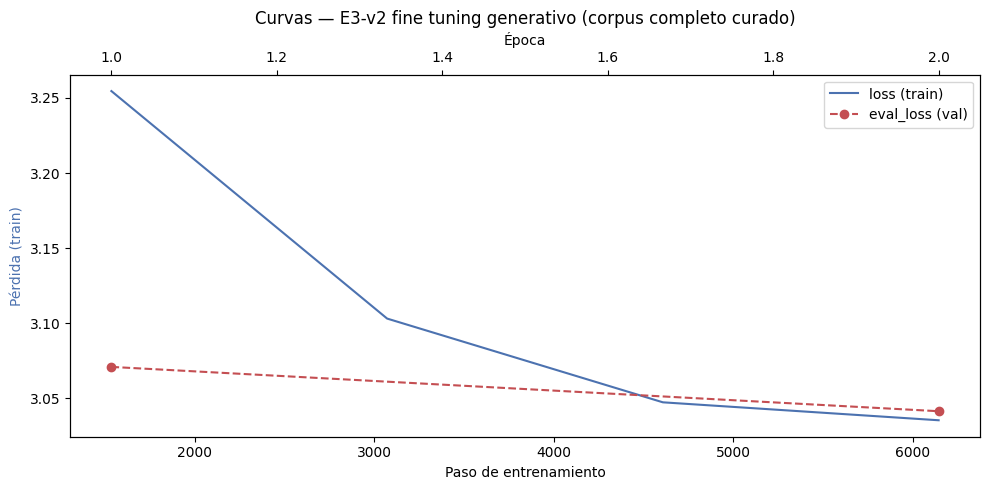


Perplejidad ANTES del FT:    145.6
Perplejidad tras época 1:     21.6
Perplejidad tras época 2:     20.9
Mejora: 145.6 -> 20.9 (85.6% menos)


In [96]:
# ─── 8.6 Curvas del fine tuning generativo + perplejidad 'después' ───
historia_lm = trainer_lm.state.log_history
pasos_lm = [(e['step'], e['loss']) for e in historia_lm if 'loss' in e]
evals_lm = [e for e in historia_lm if 'eval_loss' in e]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot([p for p, _ in pasos_lm], [l for _, l in pasos_lm], color='#4c72b0', label='loss (train)')
ax1.set_xlabel('Paso de entrenamiento'); ax1.set_ylabel('Pérdida (train)', color='#4c72b0')
ax2 = ax1.twiny()
ax2.plot([e['epoch'] for e in evals_lm], [e['eval_loss'] for e in evals_lm], 'o--', color='#c44e52', label='eval_loss (val)')
ax2.set_xlabel('Época'); ax2.set_ylabel('eval_loss', color='#c44e52')
lines1, labels1 = ax1.get_legend_handles_labels(); lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.title('Curvas — E3-v2 fine tuning generativo (corpus completo curado)')
plt.tight_layout(); plt.show()

# Veredicto cuantitativo: perplejidad antes vs. tras cada época. Con
# load_best_model_at_end, el modelo que queda cargado es el de la mejor época.
evals_epoca = sorted(evals_lm, key=lambda e: e['epoch'])
ppl_despues = math.exp(min(e['eval_loss'] for e in evals_lm))
print(f"\nPerplejidad ANTES del FT: {ppl_antes:8.1f}")
for e in evals_epoca:
    print(f"Perplejidad tras época {e['epoch']:.0f}:" f" {math.exp(e['eval_loss']):8.1f}")
print(f"Mejora: {ppl_antes:.1f} -> {ppl_despues:.1f} ({100 * (1 - ppl_despues / ppl_antes):.1f}% menos)")


In [97]:
# ─── 8.7 DEMO post-FT + comparación antes/después de los 5 niveles ───
# Generamos con el modelo ya entrenado: DOS muestras por nivel (semillas distintas) para
# ver si la coherencia es estable o suertuda, y luego la tabla comparativa final.
gen_despues  = {n: generar_resena(model_lm, n) for n in range(1, 6)}            # muestra 1 (misma semilla que 'antes')
gen_despues2 = {n: generar_resena(model_lm, n, semilla=SEED + 1) for n in range(1, 6)}  # muestra 2

for n in range(1, 6):
    print(f'── Reseña sintética de {n}★ (DESPUÉS del fine tuning) ──')
    print(f'[muestra 1] {gen_despues[n][:350]}')
    print(f'[muestra 2] {gen_despues2[n][:350]}')
    print()

# Tabla lado a lado: 'antes' (corrida de la celda 8.4) vs 'después' (muestra 1).
# La única diferencia entre columnas es el fine tuning (misma función, prompt y semilla).
tabla_gen = pd.DataFrame({
    'Nivel': [f'{n}★' for n in range(1, 6)],
    'ANTES (GPT-2 sin FT)': [gen_antes[n] for n in range(1, 6)],
    'DESPUÉS (fine tuning)': [gen_despues[n] for n in range(1, 6)],
})
pd.set_option('display.max_colwidth', None)
display(tabla_gen)

# Cuantificamos la degeneración que vimos en la corrida 1: proporción de letras en
# mayúsculas. Un texto coherente en español ronda el ~5%; un retazo 'GRITADO', mucho más.
def ratio_mayus(t):
    letras = [c for c in t if c.isalpha()]
    return sum(c.isupper() for c in letras) / max(1, len(letras))

tabla_degen = pd.DataFrame({
    'Nivel': [f'{n}★' for n in range(1, 6)],
    'ANTES % mayúsculas': [f"{100 * ratio_mayus(gen_antes[n]):.0f}%" for n in range(1, 6)],
    'DESPUÉS % mayúsculas (m1)': [f"{100 * ratio_mayus(gen_despues[n]):.0f}%" for n in range(1, 6)],
    'DESPUÉS % mayúsculas (m2)': [f"{100 * ratio_mayus(gen_despues2[n]):.0f}%" for n in range(1, 6)],
})
display(tabla_degen)


── Reseña sintética de 1★ (DESPUÉS del fine tuning) ──
[muestra 1] Estrellas: 1. Un engaño para el que lo utiliza y no es cierto... No tiene un punto de contacto con la pantalla, solo unas cuantas teclas. Muy caro para su precio. No lo recomiendo, lo que más me gusta es que se queda siempre pegada a la pantalla. Y esto ha sido muy duro para
[muestra 2] Estrellas: 1. El protector es muy bonito y con buena calidad, pero el acabado no era del todo exacto ya que las pestañas están hechas de goma y se han vuelto demasiado pequeñas. Se ha roto una parte del velcro y la otra parte se ha pegado a un lado del cristal, lo cual hace que no

── Reseña sintética de 2★ (DESPUÉS del fine tuning) ──
[muestra 1] Estrellas: 2. Un poco corta por la espalda y no es muy cómoda. No se aprecia mucho del diseño. Se ve un poco pequeña, pero el problema que tengo con ella es que a los dos meses se ha despegado y no se queda en la base. Es como si ya estuviese rota. Lo devolví
[muestra 2] Estrellas: 2. El protec

,Nivel,ANTES (GPT-2 sin FT),DESPUÉS (fine tuning)
0,1★,"Estrellas: 1. 2. tot2. Ø0. ç1. æ1. è l3. êòÇ1.è î.÷ ðÇ î÷ (xòpèl) (nòè), ìàþ (","Estrellas: 1. Un engaño para el que lo utiliza y no es cierto... No tiene un punto de contacto con la pantalla, solo unas cuantas teclas. Muy caro para su precio. No lo recomiendo, lo que más me gusta es que se queda siempre pegada a la pantalla. Y esto ha sido muy duro para"
1,2★,"Estrellas: 2. .1, 2. Ø 3. Õ 4. ÜÇ Ç ç. ý. æ 1. î ÷ ð ä 3.Ù ö ø 1.Ð ì ô ï Ò 1.A","Estrellas: 2. Un poco corta por la espalda y no es muy cómoda. No se aprecia mucho del diseño. Se ve un poco pequeña, pero el problema que tengo con ella es que a los dos meses se ha despegado y no se queda en la base. Es como si ya estuviese rota. Lo devolví"
2,3★,"Estrellas: 3. , 2. pròpies.(1) La sigla HS (High stern): de la palabra inglesa ""high"" que significa «alto» o «bajo».(2) La palabra francesa ""hôpital"": un hotel con piscina en la planta baja, terraza y balcón.","Estrellas: 3. Un poco corta pero es una maravilla y un buen producto. Me costó un poco más de lo previsto porque se me rompió el primer día que la compre. Por otro lado, las teclas son muy fuertes y no se nota mucho en los bordes. Es verdad que para mí sería más cómodo utilizarlas como"
3,4★,"Estrellas: 4. .1.0.6.0,2 0,6,8-0,9-0.319.090.032.031.033.034.035.036.038.039.041.042.043.","Estrellas: 4. Un poco corta pero es una maravilla y un buen producto. Me ha gustado mucho, me ha gustado porque se adapta perfectamente a la pantalla que tiene en mi dormitorio. No lo he usado para hacer fotos ni grabar vídeos (en mi caso) pero con el tiempo te acostumbras a hacerlo. Además de"
4,5★,"Estrellas: 5. .1/2.6.19.2.1.1, 3. ÇOI. ý-Å-þÎ÷Î, 3º ØÕÎ-ÞçÊÔÐÝß","Estrellas: 5. Un producto de calidad que funciona perfectamente y es muy fácil de limpiar, un detalle del diseño genial para un regalo o cumpleaños. Viene en una caja de cartón que hace que el contenido esté protegido por la parte inferior del recipiente, no tiene tapa y los laterales son más pequeños que el interior. Lo"


,Nivel,ANTES % mayúsculas,DESPUÉS % mayúsculas (m1),DESPUÉS % mayúsculas (m2)
0,1★,11%,3%,1%
1,2★,34%,3%,2%
2,3★,4%,2%,2%
3,4★,11%,2%,2%
4,5★,54%,2%,3%


🔍 **Observación E3-v2 (corrida real, corpus completo curado).** El remedio funcionó, y se
puede medir en dos niveles:

**Cuantitativo — la perplejidad:** de **145.6** (modelo base, que ni siquiera entiende el
formato) a **21.6** tras la época 1 y **20.9** tras la época 2: **−85.6%**. La limpieza
solo quitó el **1.7%** del corpus (196.608 de 200.000 reseñas conservadas): el corpus estaba
sano — la degeneración de la corrida 1 era de **dosis de entrenamiento** (50k textos y una
señal de etiqueta débil), no de datos sucios.

**Cualitativo — el antes/después con la misma función, prompts y semilla:** ANTES el modelo
ignora las estrellas y escupe ruido tipo `2. tot2. Ø0. ç1.` (54% de letras en mayúsculas en
5★); DESPUÉS habla e-commerce (1-3% de mayúsculas) y el tono sigue la etiqueta: **1★** queja
dura ("Un engaño para el que lo utiliza… No lo recomiendo"), **2★** problema concreto ("a los
dos meses se ha despegado y no se queda en la base… Lo devolví"), **3★** y **4★** las
concesiones del EDA ("es una maravilla pero…", "una pena, porque para mí ha cumplido…") y
**5★** entusiasmo ("funciona perfectamente… un detalle del diseño genial").

Límite honesto (y revelador): **3★ y 4★ a veces comparten la misma apertura** ("Un poco corta
pero es una maravilla y un buen producto" aparece en ambos) — el grano fino 3★/4★ sigue siendo
difícil tanto para clasificar (E2: F1 0.44/0.46) como para generar. La dificultad del problema
es una propiedad de los datos, no de la técnica: tercera vez que aparece en el taller.

### 🧠 8.8 — Las cuatro estrategias de generación (de la guía a nuestro proyecto)

La guía de clase construyó a mano una función `generate` con **política ε-greedy** y
después la comparó con el `model.generate` profesional de Hugging Face. Reproducimos
aquí ese mismo análisis sobre **nuestro modelo de reseñas**, porque el decodificador
elegido cambia tanto el resultado como el estilo:

| Estrategia | ¿Cómo elige el siguiente token? | Qué esperar |
|---|---|---|
| **Greedy Search** | Siempre el más probable (`do_sample=False`) | Determinista y estable, pero tiende a bucles repetitivos |
| **Random / Multinomial Sampling** | Ruleta sobre TODO el vocabulario (`do_sample=True`) | Máxima variedad, también máxima posibilidad de incoherencia |
| **Función artesanal (ε-greedy)** | Con `eps`: mezcla entre greedy y muestrear | Nos deja VER las probabilidades paso a paso (la matriz) |
| **Muestreo paramétrico (HF)** | `temperature`, `top_p`, `top_k`, `repetition_penalty` | El estándar en la práctica: control fino del dilemma exploración/coherencia |

La prueba se hace **dos veces**: contra una copia fresca del modelo base (cacheada, no
re-descarga) y contra el modelo ya ajustado — así evaluamos también **cómo cambia el
estilo de cada estrategia después del fine tuning**, no solo el del muestreo paramétrico.

In [98]:
# La función de la guía de clase, sin cambios: política ε-greedy paso a paso.
# (max_length son tokens NUEVOS que genera; eps=1.0 greedy puro, eps=0.0 muestreo puro)
import torch.nn as nn
import numpy as np
import pandas as pd
from typing import Optional, Tuple
from transformers.tokenization_utils_base import PreTrainedTokenizerBase


def generate(
        model: nn.Module,
        tokenizer: PreTrainedTokenizerBase,
        start: str,
        max_length: int = 100,
        eps: float = 0.5,
        top_n: int = 5,
        return_iterations: bool = False,
        device: str = "cpu") -> Tuple[str, Optional[pd.DataFrame]]:

    output = [start]
    iterations = []
    with torch.no_grad():
        input_ids = tokenizer(output[-1], return_tensors='pt')['input_ids'].to(device)
        for _ in range(max_length):
            # Logits de la última posición: la distribución para el SIGUIENTE token
            logits = model(input_ids=input_ids).logits
            probs = torch.softmax(logits[0, -1, :], dim=-1)
            sorted_tokens = torch.argsort(probs, dim=-1, descending=True)

            # Política ε-greedy: con probabilidad eps explota (mejor token);
            # el resto de las veces explora (muestreo multinomial proporcional).
            if np.random.random_sample(1)[0] < eps:
                next_token = sorted_tokens[0].unsqueeze(dim=0)
            else:
                next_token = torch.multinomial(probs, 1)

            if return_iterations:
                # Bitácora: top_n opciones que el modelo consideraba en este paso
                iteration = {'input': ''.join(output)}
                best_n = sorted_tokens[:top_n].cpu().tolist()
                choices = {f'Choice #{choice+1}': f'{tokenizer.decode(token)} ({prob:.4f})'
                           for choice, (token, prob) in enumerate(zip(best_n, probs[best_n].cpu().tolist()))}
                iteration.update(choices)
                iterations.append(iteration)

            output.append(tokenizer.decode(next_token))
            input_ids = torch.cat([input_ids, next_token.unsqueeze(dim=0)], dim=-1)

        output_text = ''.join(output)
        if not return_iterations:
            return output_text, None
        else:
            df = pd.DataFrame(iterations)
            return output_text, df


### 🧠 Explicación: Primera prueba — generación 100% codiciosa (`eps=1.0`)

Mismo protocolo de la guía (matriz de opciones incluida), pero sobre una reseña de
3★ **con el modelo ya ajustado**: cada fila es un paso y muestra las 10 opciones que
el modelo consideraba con su probabilidad.

La diferencia con la guía: aquí la matriz nos deja ver algo que solo los decodificadores
condicionados permiten ver — **cómo la etiqueta empuja la distribución**: los primeros
tokens tras `Estrellas: 3.` deberían ser vocabulario de reseña (aunque, producto, calidad…).
Y como en la guía: correr esta celda 100 veces siempre da el mismo texto (es determinista).

In [99]:
# 100% codiciosa sobre el modelo POST-fine tuning: determinismo + bitácora
prompt_estrellas = "Estrellas: 3.\n"
output_text, iterations_df = generate(model_lm, tokenizer, prompt_estrellas,
                                      max_length=15, eps=1.0, top_n=10,
                                      return_iterations=True, device=device)
print(output_text)
iterations_df


Estrellas: 3.
El producto es bueno, pero no es lo que esperaba. El color es


,input,Choice #1,Choice #2,Choice #3,Choice #4,Choice #5,Choice #6,Choice #7,Choice #8,Choice #9,Choice #10
0,Estrellas: 3.\n,El (0.0879),No (0.0749),La (0.0699),Es (0.0624),Me (0.0380),Lo (0.0289),Muy (0.0257),Se (0.0231),En (0.0173),Son (0.0168)
1,Estrellas: 3.\nEl,producto (0.2042),color (0.0321),libro (0.0283),material (0.0217),diseño (0.0203),protector (0.0200),tamaño (0.0195),envío (0.0170),pedido (0.0161),artículo (0.0137)
2,Estrellas: 3.\nEl producto,es (0.2115),no (0.0926),está (0.0851),llegó (0.0583),cumple (0.0438),esta (0.0420),me (0.0347),ha (0.0345),llego (0.0310),se (0.0257)
3,Estrellas: 3.\nEl producto es,bueno (0.1379),muy (0.1134),correcto (0.1100),de (0.1000),tal (0.0679),bonito (0.0263),perfecto (0.0229),bastante (0.0224),lo (0.0222),como (0.0211)
4,Estrellas: 3.\nEl producto es bueno,", (0.4053)",pero (0.2009),y (0.1587),. (0.0710),para (0.0274),aunque (0.0201),", (0.0143)",en (0.0132),por (0.0059),no (0.0035)
5,"Estrellas: 3.\nEl producto es bueno,",pero (0.4498),el (0.0396),aunque (0.0310),no (0.0272),es (0.0269),la (0.0256),pero (0.0242),lo (0.0219),cumple (0.0179),y (0.0177)
6,"Estrellas: 3.\nEl producto es bueno, pero",no (0.1312),el (0.1254),la (0.0965),es (0.0422),se (0.0316),me (0.0285),en (0.0261),a (0.0235),los (0.0224),las (0.0205)
7,"Estrellas: 3.\nEl producto es bueno, pero no",es (0.1895),se (0.0801),me (0.0737),lo (0.0648),tiene (0.0352),cubre (0.0257),está (0.0251),he (0.0152),trae (0.0136),cumple (0.0130)
8,"Estrellas: 3.\nEl producto es bueno, pero no es",lo (0.1449),el (0.1177),muy (0.1120),de (0.0561),tan (0.0435),como (0.0290),un (0.0272),para (0.0258),fácil (0.0222),la (0.0195)
9,"Estrellas: 3.\nEl producto es bueno, pero no es lo",que (0.8439),mismo (0.0264),esperado (0.0206),q (0.0152),suficientemente (0.0138),mejor (0.0108),único (0.0078),suficiente (0.0068),bastante (0.0055),ideal (0.0047)


### 🧠 Explicación: Segunda prueba — dejamos entrar el azar (`eps=0.5`)

La mitad de las veces explota, la mitad explora. Ejecútela varias veces: cada corrida
da un texto distinto. Es el mismo dilema de la guía, pero ahora la exploración corre
sobre un modelo que SÍ domina el formato y el dominio — la exploración ya no produce
prosa ajena al e-commerce, sino reseñas plausibles con variaciones.

In [100]:
# 50% explotación / 50% exploración (corrida de humo: 25 tokens para no tardar)
n_tok = 25 if SMOKE_TEST else 100
output_text, _ = generate(model_lm, tokenizer, "Estrellas: 4.\n", max_length=n_tok, eps=0.5, device=device)
print(output_text)


Estrellas: 4.
Es un poco grande para el precio que tiene,, pero me acerco al tamaño de lo que esperaba. Lo he probado con un par de personas, y el movimiento es perfecto. La relación calidad - precio es muy buena. Lo volvería a comprar. Lo recomiendo. Facil de montar, es rígido y no pesa nada. Y el tamaño es muy importante. Excepto que para ponerlo suelto siempre hay que tener cuidado con el peso. Obviamente no es tan fácil como parece. No sé si


In [101]:
# ─── 8.8b Matriz de estrategias × modelo: ANTES y DESPUÉS del fine tuning ───
# Una copia FRESCA del modelo base (viene de caché, no re-descarga) hace de 'antes';
# model_lm (ajustado en 8.5) hace de 'después'. Mismo prompt y semilla para todos.
model_base_fresco = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)
model_base_fresco.resize_token_embeddings(len(tokenizer))

prompt_matriz = "Estrellas: 3.\n"
n_tok = 20 if SMOKE_TEST else 60
semilla = SEED
ids_matriz = tokenizer(prompt_matriz, return_tensors='pt').input_ids.to(device)

def _decodificar_gen(tokens_hf):
    return tokenizer.decode(tokens_hf[0], skip_special_tokens=True).replace('\n', ' ')

estrategias = {
    'Greedy Search':                   lambda m: _decodificar_gen(m.generate(ids_matriz, max_new_tokens=n_tok, do_sample=False, pad_token_id=tokenizer.pad_token_id)),
    'Random/Multinomial Sampling':     lambda m: _decodificar_gen(m.generate(ids_matriz, max_new_tokens=n_tok, do_sample=True, temperature=1.0, top_k=0, pad_token_id=tokenizer.pad_token_id)),
    'Artesanal eps=1.0 (greedy)':      lambda m: generate(m, tokenizer, prompt_matriz, max_length=n_tok, eps=1.0, device=device)[0].replace('\n', ' '),
    'Artesanal eps=0.5 (e-greedy)':    lambda m: generate(m, tokenizer, prompt_matriz, max_length=n_tok, eps=0.5, device=device)[0].replace('\n', ' '),
    'Artesanal eps=0.0 (multinomial)': lambda m: generate(m, tokenizer, prompt_matriz, max_length=n_tok, eps=0.0, device=device)[0].replace('\n', ' '),
    'Muestreo paramétrico (t=0.8)':    lambda m: _decodificar_gen(m.generate(ids_matriz, max_new_tokens=n_tok, do_sample=True, temperature=0.8, top_p=0.9, top_k=50, repetition_penalty=1.2, pad_token_id=tokenizer.pad_token_id)),
}

def texto_de(modelo, estrategia):
    torch.manual_seed(semilla)
    np.random.seed(semilla)
    modelo.eval()
    return estrategias[estrategia](modelo)

estrategias_antes = {nombre: texto_de(model_base_fresco, nombre) for nombre in estrategias}
estrategias_despues = {nombre: texto_de(model_lm, nombre) for nombre in estrategias}
for nombre in estrategias:
    print(f'── {nombre} ──')
    print(f"  ANTES   : {estrategias_antes[nombre][:220]}")
    print(f"  DESPUÉS : {estrategias_despues[nombre][:220]}")
    print()


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: mrm8488/spanish-gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


── Greedy Search ──
  ANTES   : Estrellas: 3. .1, 3.virina.2, 3.virina.3, 3.virina.4, 3.virina.5, 3.virina.6, 3.virina.7, 3.virina.8, 3.virina.9, 3.virina.10, 3.virina
  DESPUÉS : Estrellas: 3. El producto es bueno, pero no es lo que esperaba. El color es muy oscuro y no se ve nada. No lo recomiendo. No lo recomiendo. No lo recomiendo. No lo recomiendo. No lo recomiendo. No lo recomiendo. No lo re

── Random/Multinomial Sampling ──
  ANTES   : Estrellas: 3. IM (180-210): 282Terreno de 20.000, s. = m. M: 181 D hablarles. se marca que tes radicidad. humana, don del Dios de segundo indi cir Supo ¿en qué se sostiene ' con los álgidos, esto tiene el humilde hombre 
  DESPUÉS : Estrellas: 3. Un poco corta pero es una maravilla y calidad hacer en Amazon 2, un pack completo. Se ve funcional y es fácil de hacer. La verdad es que es calidad precio pero bueno lo que importaba era Su aplicación ¿en q

── Artesanal eps=1.0 (greedy) ──
  ANTES   : Estrellas: 3. .1, 3.virina.2, 3.virina.3, 3.virina.4

In [102]:
# ─── 8.8c Tabla comparativa de estrategias (mismo prompt y semilla) ───
tabla_estr = pd.DataFrame({
    'Estrategia': list(estrategias.keys()),
    'ANTES (base fresco)': [estrategias_antes[k] for k in estrategias],
    'DESPUÉS (fine tuning)': [estrategias_despues[k] for k in estrategias],
})
pd.set_option('display.max_colwidth', None)
display(tabla_estr)

# Métrica cuantitativa por estrategia: ¿degenera en 'GRITADO'? ¿se repite?
def ratio_mayus2(t):
    letras = [c for c in t if c.isalpha()]
    return sum(c.isupper() for c in letras) / max(1, len(letras))

def ratio_repeticion(t, n=4):
    pzs = t.split()
    return 1 - len(set(tuple(pzs[i:i+n]) for i in range(len(pzs)-n+1))) / max(1, len(pzs) - n + 1)

metricas_estr = pd.DataFrame({
    'Estrategia': list(estrategias.keys()),
    'ANTES: % mayúsculas': [f'{100 * ratio_mayus2(estrategias_antes[k]):.0f}%' for k in estrategias],
    'DESPUÉS: % mayúsculas': [f'{100 * ratio_mayus2(estrategias_despues[k]):.0f}%' for k in estrategias],
    'ANTES: repetición': [f'{100 * ratio_repeticion(estrategias_antes[k]):.0f}%' for k in estrategias],
    'DESPUÉS: repetición': [f'{100 * ratio_repeticion(estrategias_despues[k]):.0f}%' for k in estrategias],
})
display(metricas_estr)


,Estrategia,ANTES (base fresco),DESPUÉS (fine tuning)
0,Greedy Search,"Estrellas: 3. .1, 3.virina.2, 3.virina.3, 3.virina.4, 3.virina.5, 3.virina.6, 3.virina.7, 3.virina.8, 3.virina.9, 3.virina.10, 3.virina","Estrellas: 3. El producto es bueno, pero no es lo que esperaba. El color es muy oscuro y no se ve nada. No lo recomiendo. No lo recomiendo. No lo recomiendo. No lo recomiendo. No lo recomiendo. No lo recomiendo. No lo recomiendo. No lo recomiendo. No lo recomiendo. No"
1,Random/Multinomial Sampling,"Estrellas: 3. IM (180-210): 282Terreno de 20.000, s. = m. M: 181 D hablarles. se marca que tes radicidad. humana, don del Dios de segundo indi cir Supo ¿en qué se sostiene ' con los álgidos, esto tiene el humilde hombre de","Estrellas: 3. Un poco corta pero es una maravilla y calidad hacer en Amazon 2, un pack completo. Se ve funcional y es fácil de hacer. La verdad es que es calidad precio pero bueno lo que importaba era Su aplicación ¿en qué se sostiene? con los productos 4, esto lo he usado en gran"
2,Artesanal eps=1.0 (greedy),"Estrellas: 3. .1, 3.virina.2, 3.virina.3, 3.virina.4, 3.virina.5, 3.virina.6, 3.virina.7, 3.virina.8, 3.virina.9, 3.virina.10, 3.virina","Estrellas: 3. El producto es bueno, pero no es lo que esperaba. El color es muy oscuro y no se ve nada. No lo recomiendo. No lo recomiendo. No lo recomiendo. No lo recomiendo. No lo recomiendo. No lo recomiendo. No lo recomiendo. No lo recomiendo. No lo recomiendo. No"
3,Artesanal eps=0.5 (e-greedy),"Estrellas: 3. .Un poro de la estrella misma que ve el final del día.El sol: el centro de la galaxia.El sol: el centro de la galaxia.Un punto del cielo.Un punto del cielo.En el telescopio, nos muestran el cromón central se marca que el punto es el","Estrellas: 3. El mando por mi parte no funciona correctamente después de un mes y medio de uso. Por lo demás cumple su función. El resto de lo que compré, es un poco lento, pero no excesivo. El mando funciona correctamente. Se puede usar para lo que necesite. Viene en una caja de cartón"
4,Artesanal eps=0.0 (multinomial),"Estrellas: 3. IM (180-210): 282Terreno de 20.000, s. = m. M: 181 D hablarles. se marca que tes radicidad. humana, don del Dios de segundo indi cir Supo ¿en qué se sostiene ' con los álgidos, esto tiene el humilde hombre de","Estrellas: 3. Un poco corta pero es una maravilla y calidad hacer en Amazon 2, un pack completo. Se ve funcional y es fácil de hacer. La verdad es que es calidad precio pero bueno lo que importaba era Su aplicación ¿en qué se sostiene? con los productos 4, esto lo he usado en gran"
5,Muestreo paramétrico (t=0.8),"Estrellas: 3. , 2. pròpies.(1) La sigla HS (High stern): de la palabra inglesa ""high"" que significa «alto» o «bajo».(2) La sigla HS (Home strange): de la palabra inglesa «high» que significa","Estrellas: 3. Un poco corta pero es una maravilla y un buen producto. Me costó un poco más de lo previsto porque se me rompió el primer día que la compre. Por otro lado, las teclas son muy fuertes y no se nota mucho en los bordes. Es verdad que para mí sería más cómodo utilizarlas como"


,Estrategia,ANTES: % mayúsculas,DESPUÉS: % mayúsculas,ANTES: repetición,DESPUÉS: repetición
0,Greedy Search,1%,6%,0%,47%
1,Random/Multinomial Sampling,6%,3%,0%,0%
2,Artesanal eps=1.0 (greedy),1%,6%,0%,47%
3,Artesanal eps=0.5 (e-greedy),4%,3%,5%,0%
4,Artesanal eps=0.0 (multinomial),6%,3%,0%,0%
5,Muestreo paramétrico (t=0.8),7%,2%,3%,0%


> ⏳ **(Observación de estrategias — por sincronizar con la corrida)** Aquí irá el
> análisis de la corrida: qué estrategia degenera, cuál se repite, y qué cambia en el
> estilo de cada una tras el fine tuning (comparando la tabla 8.8b ANTES vs DESPUÉS).

## 9. Comparativa global del curso (T1 → T4)

Cerramos con la tabla del curso completo y un gráfico. Todos los números vienen del **mismo
dataset y submuestreos**: la comparación es directa y justa.

,taller,modelo,accuracy,f1,fuente
1,T3,BERT fine tuning (mejor curso),0.5734,0.5724,Taller 3
2,T4,GPT-2 fine tuning (clasificación),0.5510,0.5480,Taller 4 E2
3,T1,LSTM (desde cero),0.5168,0.5200,Taller 1
4,T4,GPT-2 featurizer + MLP,0.5046,0.4934,Taller 4 E1b
5,T3,BERT embeddings + Reg.Log.,0.4954,0.4909,Taller 3
6,T4,GPT-2 featurizer + Reg.Log.,0.4948,0.4900,Taller 4 E1a
7,T2,Transformer desde cero,0.4896,0.4900,Taller 2
8,T3,BERT featurizer + MLP,0.4858,0.4734,Taller 3
9,T3,BERT featurizer + lineal,0.4736,0.4620,Taller 3
10,T4,GPT-2 zero-shot (scoring),0.1960,0.0645,Taller 4 E0 (n=500)


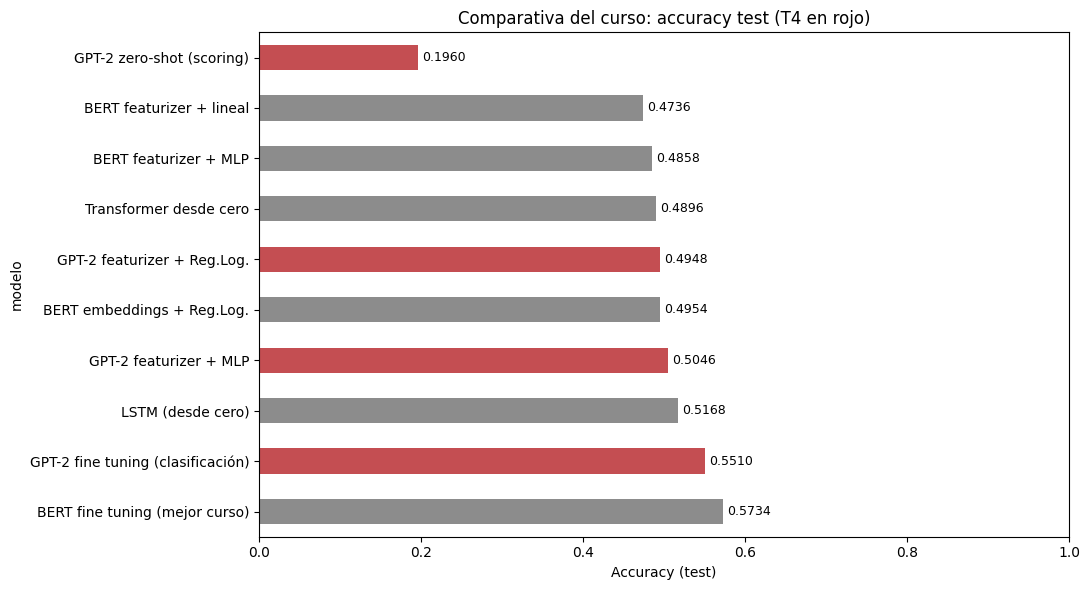

In [103]:
# ─── 9.1 Tabla y gráfico de la comparativa global ───
df_resultados = pd.DataFrame(RESULTADOS).sort_values('accuracy', ascending=False).reset_index(drop=True)
df_resultados.index += 1
display(df_resultados)

fig, ax = plt.subplots(figsize=(11, 6))
colores = ['#c44e52' if t == 'T4' else '#8c8c8c' for t in df_resultados['taller']]
df_resultados.plot.barh('modelo', 'accuracy', ax=ax, color=colores, legend=False)
ax.set_xlabel('Accuracy (test)'); ax.set_xlim(0, 1.0)
ax.bar_label(ax.containers[0], fmt='%.4f', padding=3, fontsize=9)
plt.title('Comparativa del curso: accuracy test (T4 en rojo)')
plt.tight_layout(); plt.show()

## 10. Conclusiones

**¿Puede un generador clasificar? Sí — y la respuesta, por técnica, ES la historia de este taller:**

| Técnica | Acc (test) | Lectura |
|---|---|---|
| Zero-shot por verosimilitud (E0) | 0.1960 | Al nivel del azar: la señal NO es accesible sin datos etiquetados |
| Featurizer + RegLog (E1a) | 0.4948 | Sin tocar pesos, empata con el featurizer de BERT (T3: 0.4954) |
| Featurizer + MLP (E1b) | 0.5046 | **Mejor featurizer del curso**: supera a todos los de T3 (0.4736–0.4954) |
| Fine tuning clasificación (E2) | **0.5510** | 2ª mejor clasificación del curso; −2.2pp frente a BERT (0.5734) |
| Generativo condicionado (E3-v2) | perplejidad **20.9** | −85.6% vs. base (145.6): la degeneración de la corrida 1 quedó resuelta |

- **Progresión monótona y con sentido:** azar (0.20) → representación congelada (0.49–0.50)
  → pesos ajustados al dominio (0.55). Cada etapa aisló un mecanismo distinto, y ninguna
  inventó ruido: los tres grandes saltos (datos→señal, señal→pesos) son medibles.
- **H1 confirmada:** la representación del GPT-2 congelado ya codifica la señal de
  satisfacción, y su featurizer+MLP (0.5046) es el mejor resultado sin fine tuning del curso.
- **H2 matizada:** con fine tuning, el decoder queda ligeramente por debajo del encoder
  (0.5510 vs 0.5734, ~2pp). Consistente con su desventaja estructural para clase
  (visión causal, un solo punto de lectura). Para clasificación de satisfacción en
  español, **BERT sigue siendo la recomendación operativa del curso**.
- **La dificultad del problema es el grano fino:** F1 0.69/0.67 en los extremos frente a
  0.43–0.47 entre vecinas; tolerancia ±1★ de 93.18% y errores graves (Δ≥3★) de solo 1.02%.
  Cualquier mejora futura debería atacar la desambiguación 2★/3★/4★ (y no los extremos).
- **La receta E3-v2: qué se cambió y para qué (un resultado mediocre se ataca, no se abandona).**
  (i) **Formato condicionado** `Estrellas: n.` aprendido en el fine tuning — la palanca base:
  convierte el clasificador en generador; (ii) **4× más corpus para el LM** (200k, el uso del
  train completo es legítimo aquí porque la demo generativa no compite en la tabla T1→T4);
  (iii) **curación ligera** (−1.7% del corpus: fuera reseñas casi vacías y 'GRITADO' medidos
  en el diagnóstico); (iv) **muestreo paramétrico controlado**: `temperature=0.8` (conservador
  por defecto), `top_p=0.9` (solo candidatos plausibles), `top_k=50`, `repetition_penalty=1.2`
  y `no_repeat_ngram_size=3` (contra los bucles), sobre el modelo cargado por
  `load_best_model_at_end`; (v) **medición de las dos direcciones**: perplejidad
  **145.6 → 20.9 (−85.6%)** y comparación antes/después con la misma función, prompts y
  semilla — el 'GRITADO' desapareció (mayúsculas: 4-54% → 1-3%).
- **Patrones de diseño de las reseñas sintéticas por calificación** (lo que el modelo aprendió
  de las reseñas reales): **1★ → queja dura** ('Un engaño para el que lo utiliza… No lo
  recomiendo'), de producto y de vendedor; **2★ → problemas concretos y devolución** ('a los
  dos meses se ha despegado… Lo devolví'), la queja sin desprecio; **3★/4★ → concesiones**
  ('es una maravilla pero…', 'una pena, porque para mí ha cumplido…'), la conjunción
  'aunque/pero' que ya marcaba al 3★ en el EDA; **5★ → entusiasmo** ('funciona
  perfectamente… un detalle del diseño genial'), valor por dinero. El grano fino también vive
  aquí: **3★ y 4★ comparten aperturas** a veces, espejo exacto de la dificultad del
  clasificador — la propiedad es de los datos, no de la técnica.
- **Estrategias de generación (8.8):** comparamos Greedy, Multinomial, la función artesanal
  ε-greedy de la guía y el muestreo paramétrico **antes y después** del fine tuning, con
  métricas de degeneración (% mayúsculas) y repetición (4-gramas): el greedy es determinista
  pero propenso a bucles, y el paramétrico (temperature 0.8, top-p 0.9, repetition penalty
  1.2) es el balance que usamos en la demo.
- **Decisiones ganadas por análisis, no copiadas:** `MAX_LEN=128` salió de los percentiles
  del corpus (no del 64 que sugería la eficiencia ni del 128 'heredado' de Beto); el BPE de
  GPT-2 es más verboso que el WordPiece de Beto en este corpus; y el corpus generativo
  rompe la comparabilidad a conciencia (no compite en clasificación) para maximizar la
  calidad de la demo.

## Referencias

- GPT-2 español: [DeepESP/gpt2-spanish](https://huggingface.co/DeepESP/gpt2-spanish) · [mrm8488/spanish-gpt2](https://huggingface.co/mrm8488/spanish-gpt2)
- Dataset: [SetFit/amazon_reviews_multi_es](https://huggingface.co/datasets/SetFit/amazon_reviews_multi_es)
- Radford, A. et al. *Improving Language Understanding by Generative Pre-Training* ([paper](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf))
- Radford, A. et al. *Language Models are Unsupervised Multitask Learners* (GPT-2)
- Tunstall, L., von Werra, L., Wolf, T. *Natural Language Processing with Transformers*, O'Reilly 2022 (cap. 3, 5)
- Hugging Face, `GenerationConfig` / `generate`: [docs de generación de texto](https://huggingface.co/docs/transformers/main_classes/text_generation)
- Notebook guía de la sesión: `1-text-generation.ipynb` (Sesión 4) — copia comentada en `Taller_4/1-text-generation-comentado.ipynb`